In [ ]:
!pip install -q datasets timm torchmetrics scikit-learn matplotlib seaborn pandas numpy Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.5 MB/s eta 0:00:00


In [ ]:
import os
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from copy import deepcopy
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from einops import rearrange
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    balanced_accuracy_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
from datasets import load_dataset, concatenate_datasets
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print('DDPM imports ready.')

Device: cuda
DDPM imports ready.


Load PlantVillage

In [ ]:
from huggingface_hub import hf_hub_download, list_repo_files
from datasets import load_dataset

raw = load_dataset('mohanty/PlantVillage', 'default')
full_ds = concatenate_datasets([raw['train'], raw['test']])

print(f'Total rows: {len(full_ds)}')
print(f'Features: {full_ds.features}')
print(f'First 5 examples:')
for i in range(5):
    print(f'  {full_ds[i]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

color_train.txt: 0.00B [00:00, ?B/s]

grayscale_train.txt: 0.00B [00:00, ?B/s]

segmented_train.txt: 0.00B [00:00, ?B/s]

...

grayscale_test.txt: 0.00B [00:00, ?B/s]

segmented_test.txt: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Total rows: 162916
Features: {'text': Value('string')}
First 5 examples:
  {'text': 'raw/color/Raspberry___healthy/a37f34f7-022d-461a-8a3d-95f5cd774e35___Mary_HL 9155.JPG'}
  {'text': 'raw/color/Raspberry___healthy/368f3c83-5bd2-4906-b418-57b6ceff9bfe___Mary_HL 9160.JPG'}
  {'text': 'raw/color/Raspberry___healthy/98226f66-15a1-40d5-9b62-04ae5b4fd8d5___Mary_HL 9159.JPG'}
  {'text': 'raw/color/Raspberry___healthy/e2bc5cd9-a590-4b06-a610-dec52f74ae1e___Mary_HL 9163.JPG'}
  {'text': 'raw/color/Raspberry___healthy/de3b86c7-8f0b-4cd8-ab11-2450fff0ec52___Mary_HL 9154.JPG'}


Inspect Class Labels

In [ ]:
all_paths = full_ds['text']

# Extract class label from folder name
def extract_label(path):
    parts = path.replace('\\', '/').split('/')
    return parts[-2]

all_class_names = [extract_label(p) for p in all_paths]
unique_classes  = sorted(set(all_class_names))

print(f'Total images  : {len(all_paths)}')
print(f'Total classes : {len(unique_classes)}')
print('\nAll classes:')
for i, n in enumerate(unique_classes):
    print(f'  {i:2d}: {n}')

Total images  : 162916
Total classes : 38

All classes:
   0: Apple___Apple_scab
   1: Apple___Black_rot
   2: Apple___Cedar_apple_rust
   3: Apple___healthy
   4: Blueberry___healthy
   5: Cherry_(including_sour)___Powdery_mildew
   6: Cherry_(including_sour)___healthy
   7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   8: Corn_(maize)___Common_rust_
   9: Corn_(maize)___Northern_Leaf_Blight
  10: Corn_(maize)___healthy
  11: Grape___Black_rot
  12: Grape___Esca_(Black_Measles)
  13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  14: Grape___healthy
  15: Orange___Haunglongbing_(Citrus_greening)
  16: Peach___Bacterial_spot
  17: Peach___healthy
  18: Pepper,_bell___Bacterial_spot
  19: Pepper,_bell___healthy
  20: Potato___Early_blight
  21: Potato___Late_blight
  22: Potato___healthy
  23: Raspberry___healthy
  24: Soybean___healthy
  25: Squash___Powdery_mildew
  26: Strawberry___Leaf_scorch
  27: Strawberry___healthy
  28: Tomato___Bacterial_spot
  29: Tomato___Early_blight


Select Tomato Classes

In [ ]:


all_paths = full_ds['text']

# Extract class label from folder name
def extract_label(path):
    parts = path.replace('\\', '/').split('/')
    return parts[-2]

all_class_names = [extract_label(p) for p in all_paths]
unique_classes  = sorted(set(all_class_names))

print(f'Total images  : {len(all_paths)}')
print(f'Total classes : {len(unique_classes)}')
print('\nAll classes:')
for i, n in enumerate(unique_classes):
    print(f'  {i:2d}: {n}')

Total images  : 162916
Total classes : 38

All classes:
   0: Apple___Apple_scab
   1: Apple___Black_rot
   2: Apple___Cedar_apple_rust
   3: Apple___healthy
   4: Blueberry___healthy
   5: Cherry_(including_sour)___Powdery_mildew
   6: Cherry_(including_sour)___healthy
   7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   8: Corn_(maize)___Common_rust_
   9: Corn_(maize)___Northern_Leaf_Blight
  10: Corn_(maize)___healthy
  11: Grape___Black_rot
  12: Grape___Esca_(Black_Measles)
  13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  14: Grape___healthy
  15: Orange___Haunglongbing_(Citrus_greening)
  16: Peach___Bacterial_spot
  17: Peach___healthy
  18: Pepper,_bell___Bacterial_spot
  19: Pepper,_bell___healthy
  20: Potato___Early_blight
  21: Potato___Late_blight
  22: Potato___healthy
  23: Raspberry___healthy
  24: Soybean___healthy
  25: Squash___Powdery_mildew
  26: Strawberry___Leaf_scorch
  27: Strawberry___healthy
  28: Tomato___Bacterial_spot
  29: Tomato___Early_blight


EDA

In [ ]:
label_names = unique_classes
name2id     = {n: i for i, n in enumerate(label_names)}

TOMATO_CLASSES = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Target_Spot',
]
SHORT_NAMES = [
    'Healthy', 'Early Blight', 'Late Blight',
    'Septoria', 'Yellow Curl', 'Target Spot'
]

# Verify all classes exist
for c in TOMATO_CLASSES:
    found = c in name2id
    #print(f'  {"yes" if found else "no"} {c}  (id={name2id.get(c, "NOT FOUND")})')

# Map: class_name -> new 0-based id (0 to 5)
name2new = {cls: i for i, cls in enumerate(TOMATO_CLASSES)}

# Filter paths AND directly assign new 0-based label
tomato_paths_remapped = []
for p in all_paths:
    cls_name = extract_label(p)
    if cls_name in name2new:
        tomato_paths_remapped.append((p, name2new[cls_name]))

print(f'\nTomato subset size: {len(tomato_paths_remapped)}')
print(f'Label distribution: {Counter([lbl for _, lbl in tomato_paths_remapped])}')

# Metadata table
orig_counts = Counter([lbl for _, lbl in tomato_paths_remapped])
meta = pd.DataFrame([
    {
        'class_name': TOMATO_CLASSES[i],
        'short_name': SHORT_NAMES[i],
        'new_id':     i,
        'count':      orig_counts[i]
    }
    for i in range(len(TOMATO_CLASSES))
])
print('\nMetadata table:')
display(meta)

Checking class names exist in dataset...

Tomato subset size: 39096
Label distribution: Counter({4: 16071, 2: 5727, 3: 5313, 0: 4773, 5: 4212, 1: 3000})

Metadata table:


,class_name,short_name,new_id,count
0,Tomato___healthy,Healthy,0,4773
1,Tomato___Early_blight,Early Blight,1,3000
2,Tomato___Late_blight,Late Blight,2,5727
3,Tomato___Septoria_leaf_spot,Septoria,3,5313
4,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Yellow Curl,4,16071
5,Tomato___Target_Spot,Target Spot,5,4212


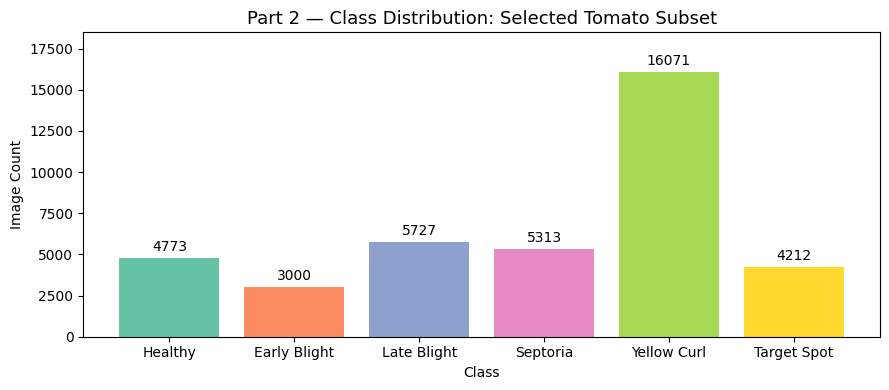

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    meta['short_name'],
    meta['count'],
    color=sns.color_palette('Set2', len(meta))
)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title('Part 2 — Class Distribution: Selected Tomato Subset', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Image Count')
ax.set_ylim(0, meta['count'].max() * 1.15)
plt.tight_layout()
plt.savefig('part2_class_distribution.png', dpi=150)
plt.show()

Download and Unzip

In [ ]:
import os
import zipfile
from huggingface_hub import hf_hub_download
from tqdm.notebook import tqdm


zip_path = hf_hub_download(
    repo_id   = 'mohanty/PlantVillage',
    filename  = 'data.zip',
    repo_type = 'dataset',
    local_dir = '/content/plantvillage'
)

print(f'Downloaded to: {zip_path}')
print(f'   File size: {os.path.getsize(zip_path) / 1e9:.2f} GB')

This may take 5–10 minutes (the zip is ~1.5GB)



data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

Downloaded to: /content/plantvillage/data.zip
   File size: 2.18 GB


In [ ]:
import os
import zipfile
from huggingface_hub import hf_hub_download
from tqdm.notebook import tqdm

zip_path = hf_hub_download(
    repo_id   = 'mohanty/PlantVillage',
    filename  = 'data.zip',
    repo_type = 'dataset',
    local_dir = '/content/plantvillage'
)

print(f'Downloaded to: {zip_path}')
print(f'   File size: {os.path.getsize(zip_path) / 1e9:.2f} GB')

This may take 5–10 minutes (the zip is ~1.5GB)

Downloaded to: /content/plantvillage/data.zip
   File size: 2.18 GB


In [ ]:
EXTRACT_DIR = '/content/plantvillage/extracted'
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(EXTRACT_DIR)

print('Unzipped!')
print('\nFolder structure:')
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 2:   # stop printing too deep
        break

Unzipping data.zip...
Unzipped!

Folder structure:
extracted/
  raw/
    color/


In [ ]:
import glob

# Find where the color images actually are:
color_dir = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if any('Tomato' in d for d in dirs):
        color_dir = root
        print(f'Found tomato folders at: {root}')
        print(f'Subfolders: {dirs[:10]}')
        break

if color_dir is None:
    print('Could not find tomato folders')
    for root, dirs, files in os.walk(EXTRACT_DIR):
        print(root)

Found tomato folders at: /content/plantvillage/extracted/raw/grayscale
Subfolders: ['Apple___healthy', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Potato___Late_blight', 'Tomato___Target_Spot', 'Grape___Black_rot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Pepper,_bell___healthy']


In [ ]:
TOMATO_CLASSES = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Target_Spot',
]
SHORT_NAMES = [
    'Healthy', 'Early Blight', 'Late Blight',
    'Septoria', 'Yellow Curl', 'Target Spot'
]
name2new = {cls: i for i, cls in enumerate(TOMATO_CLASSES)}

tomato_paths_remapped = []
for cls_name, new_id in name2new.items():
    cls_dir = os.path.join(color_dir, cls_name)
    if not os.path.exists(cls_dir):
        print(f'Not found: {cls_dir}')
        continue
    files = glob.glob(os.path.join(cls_dir, '*.jpg')) + \
            glob.glob(os.path.join(cls_dir, '*.JPG')) + \
            glob.glob(os.path.join(cls_dir, '*.png')) + \
            glob.glob(os.path.join(cls_dir, '*.PNG'))
    for f in files:
        tomato_paths_remapped.append((f, new_id))
    print(f'  {SHORT_NAMES[new_id]:<20} : {len(files)} images')

print(f'\nTotal tomato images: {len(tomato_paths_remapped)}')

  Healthy              : 1591 images
  Early Blight         : 1000 images
  Late Blight          : 1908 images
  Septoria             : 1771 images
  Yellow Curl          : 5357 images
  Target Spot          : 1404 images

Total tomato images: 13031


In [ ]:
class PlantDataset(Dataset):
    def __init__(self, paths, labels, transform,
                 minority_ids=None, minority_transform=None):
        self.paths              = paths
        self.labels             = np.array(labels)
        self.transform          = transform
        self.minority_ids       = set(minority_ids) if minority_ids else set()
        self.minority_transform = minority_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        label = int(self.labels[idx])

        # Load from local disk — fast & reliable
        img = Image.open(path).convert('RGB')

        if label in self.minority_ids and self.minority_transform:
            img = self.minority_transform(img)
        else:
            img = self.transform(img)

        return img, label

print('PlantDataset (local disk) defined.')

PlantDataset (local disk) defined.


In [ ]:
all_paths_list = [p for p, _ in tomato_paths_remapped]
all_labels     = np.array([l for _, l in tomato_paths_remapped])

print(f'Total samples      : {len(all_paths_list)}')
print(f'Class distribution : {Counter(all_labels)}')

Total samples      : 13031
Class distribution : Counter({np.int64(4): 5357, np.int64(2): 1908, np.int64(3): 1771, np.int64(0): 1591, np.int64(5): 1404, np.int64(1): 1000})


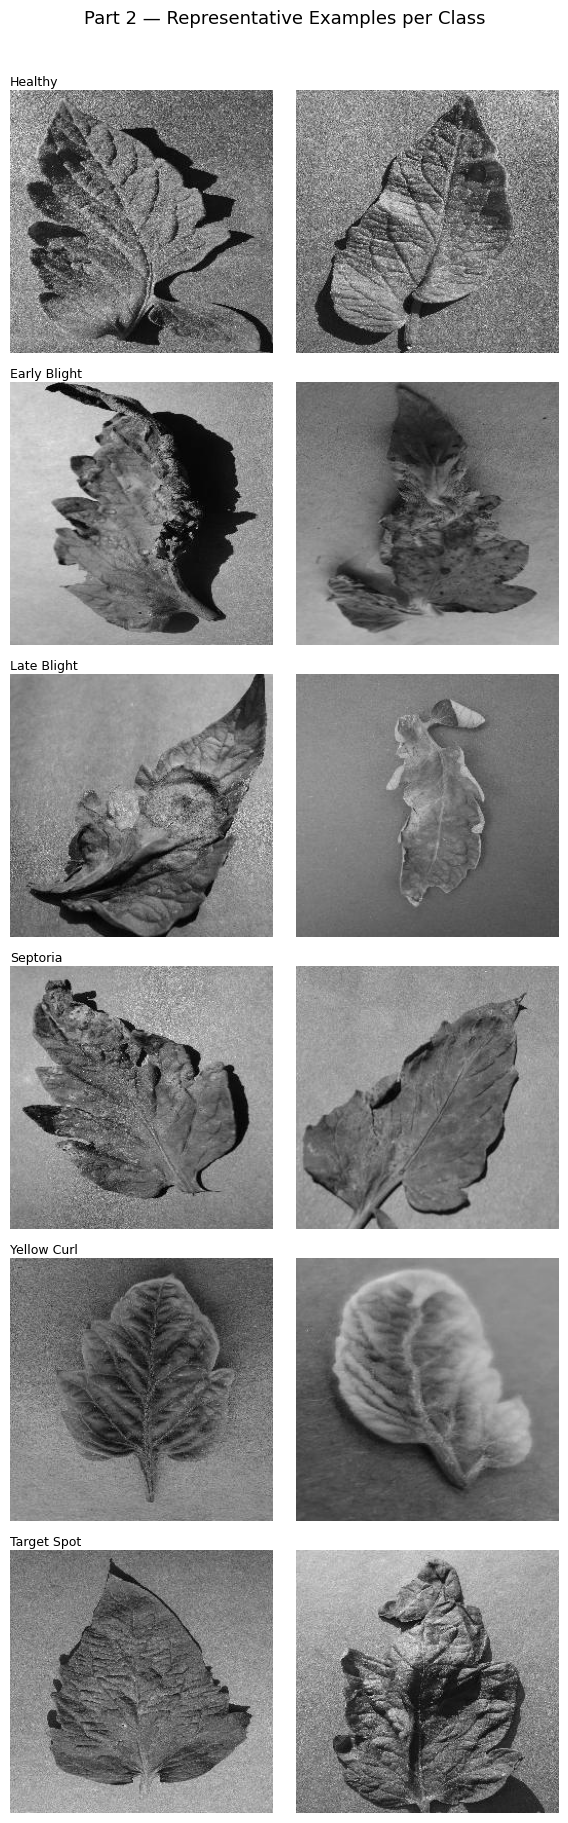

In [ ]:
n_cls      = len(TOMATO_CLASSES)
N_EXAMPLES = 2

# Group paths by label
class_to_paths = {i: [] for i in range(n_cls)}
for path, lbl in tomato_paths_remapped:
    class_to_paths[lbl].append(path)

fig, axes = plt.subplots(n_cls, N_EXAMPLES,
                          figsize=(N_EXAMPLES * 3, n_cls * 3))

for row_idx in range(n_cls):
    samples = random.sample(class_to_paths[row_idx],
                            min(N_EXAMPLES, len(class_to_paths[row_idx])))
    for col, path in enumerate(samples):
        img = Image.open(path).convert('RGB')
        axes[row_idx, col].imshow(img)
        axes[row_idx, col].axis('off')
        if col == 0:
            axes[row_idx, col].set_title(
                SHORT_NAMES[row_idx], fontsize=9, loc='left', pad=3
            )

fig.suptitle('Part 2 — Representative Examples per Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('part2_image_panel.png', dpi=150, bbox_inches='tight')
plt.show()

Stratified Split

In [ ]:
indices = np.arange(len(all_labels))

# 70% train / 30% temp
idx_train, idx_temp, _, y_temp = train_test_split(
    indices, all_labels, test_size=0.30,
    stratify=all_labels, random_state=SEED
)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=SEED
)

# Split paths and labels
train_paths_balanced  = [all_paths_list[i] for i in idx_train]
train_labels_balanced = all_labels[idx_train]

val_paths   = [all_paths_list[i] for i in idx_val]
val_labels  = all_labels[idx_val]

test_paths  = [all_paths_list[i] for i in idx_test]
test_labels = all_labels[idx_test]

print(f'Train : {len(train_paths_balanced)} images')
print(f'Val   : {len(val_paths)}   images')
print(f'Test  : {len(test_paths)}  images')

Train : 9121 images
Val   : 1955   images
Test  : 1955  images


Define Transform

In [ ]:
IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Standard — no augmentation
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Val / Test
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Classical augmentation
aug_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


Custom Dataset Class

In [ ]:
class PlantDataset(Dataset):
    def __init__(self, paths, labels, transform,
                 minority_ids=None, minority_transform=None):
        self.paths              = paths
        self.labels             = np.array(labels)
        self.transform          = transform
        self.minority_ids       = set(minority_ids) if minority_ids else set()
        self.minority_transform = minority_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        label = int(self.labels[idx])

        img = Image.open(path).convert('RGB')

        if label in self.minority_ids and self.minority_transform:
            img = self.minority_transform(img)
        else:
            img = self.transform(img)

        return img, label

print('PlantDataset class defined.')

PlantDataset class defined.


Build Validation and Test Loaders

In [ ]:
val_dataset  = PlantDataset(val_paths,  val_labels,  val_transform)
test_dataset = PlantDataset(test_paths, test_labels, val_transform)

val_loader  = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f'Val  loader : {len(val_dataset)} samples')
print(f'Test loader : {len(test_dataset)} samples')

Val  loader : 1955 samples
Test loader : 1955 samples


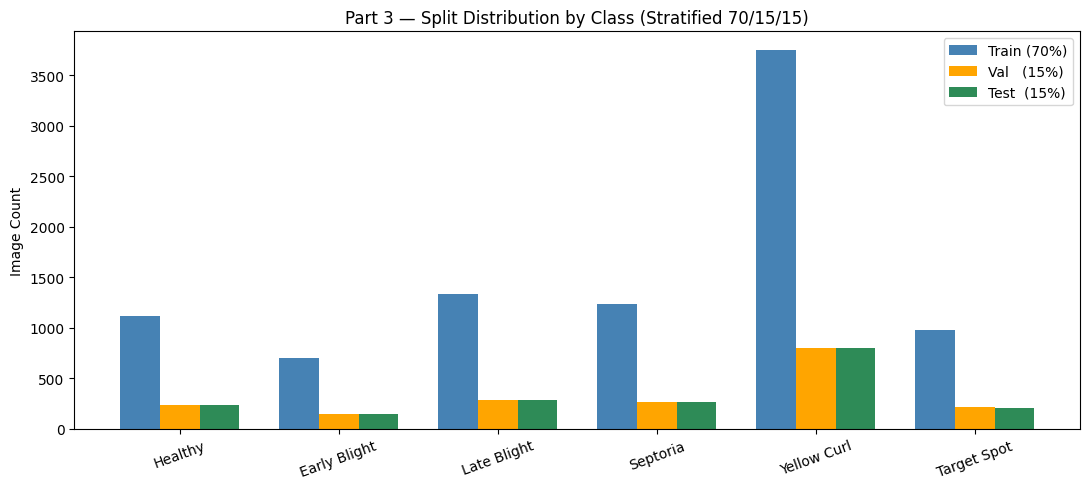

In [ ]:
def count_per_class(indices, labels, n_classes):
    c = Counter(labels[indices])
    return [c.get(i, 0) for i in range(n_classes)]

x     = np.arange(n_cls)
width = 0.25

tr_cnt = count_per_class(idx_train, all_labels, n_cls)
va_cnt = count_per_class(idx_val,   all_labels, n_cls)
te_cnt = count_per_class(idx_test,  all_labels, n_cls)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, tr_cnt, width, label='Train (70%)', color='steelblue')
ax.bar(x,         va_cnt, width, label='Val   (15%)', color='orange')
ax.bar(x + width, te_cnt, width, label='Test  (15%)', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, rotation=20)
ax.set_ylabel('Image Count')
ax.set_title('Part 3 — Split Distribution by Class (Stratified 70/15/15)')
ax.legend()
plt.tight_layout()
plt.savefig('part3_split_distribution.png', dpi=150)
plt.show()

All Helper Functions

In [ ]:
NUM_CLASSES = len(TOMATO_CLASSES)

def build_efficientnet(num_classes=NUM_CLASSES):
    model = timm.create_model(
        'efficientnet_b0', pretrained=True, num_classes=num_classes
    )
    return model.to(DEVICE)


def make_loader(paths, labels, transform, batch_size=32, shuffle=True,
                minority_ids=None, minority_transform=None):
    ds = PlantDataset(paths, labels, transform, minority_ids, minority_transform)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2)


def train_model(model, train_loader, val_loader,
                criterion, n_epochs=20, lr=1e-3, label='model'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history    = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1    = 0.0
    best_state = None

    for epoch in range(1, n_epochs + 1):
        # Train
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # Validate
        model.eval()
        val_loss = 0.0
        preds_all, true_all = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item() * imgs.size(0)
                preds_all.extend(out.argmax(1).cpu().numpy())
                true_all.extend(labels.cpu().numpy())
        val_loss /= len(val_loader.dataset)
        val_f1    = f1_score(true_all, preds_all, average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        scheduler.step()

        if val_f1 > best_f1:
            best_f1    = val_f1
            best_state = deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d}/{n_epochs} | '
                  f'train={train_loss:.4f}  val={val_loss:.4f}  F1={val_f1:.4f}')

    model.load_state_dict(best_state)
    print(f'[{label}]  Best val macro F1 = {best_f1:.4f}')
    return model, history


def evaluate(model, loader, split_name='Test'):
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds_all.extend(model(imgs).argmax(1).cpu().numpy())
            true_all.extend(labels.numpy())
    preds_all = np.array(preds_all)
    true_all  = np.array(true_all)

    acc      = accuracy_score(true_all, preds_all)
    macro_f1 = f1_score(true_all, preds_all, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(true_all, preds_all)
    recalls  = recall_score(true_all, preds_all, average=None, zero_division=0)
    min_rec  = recalls.min()

    print(f'\n── {split_name} ──────────────────────────────')
    print(f'  Accuracy          : {acc:.4f}')
    print(f'  Macro F1          : {macro_f1:.4f}')
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Minority Recall   : {min_rec:.4f}')
    print(f'  Per-class Recall  : {np.round(recalls, 4)}')

    return {
        'accuracy': acc, 'macro_f1': macro_f1,
        'balanced_accuracy': bal_acc,
        'minority_recall': min_rec,
        'per_class_recall': recalls,
        'preds': preds_all, 'true': true_all
    }

print('helper functions ready.')

All helper functions ready.


Train Balanced Benchmark

In [ ]:
balanced_loader = make_loader(
    train_paths_balanced, train_labels_balanced, train_transform
)
criterion = nn.CrossEntropyLoss()

model_p4 = build_efficientnet()
model_p4, hist_p4 = train_model(
    model_p4, balanced_loader, val_loader,
    criterion, n_epochs=20, label='Part4-Balanced'
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[Part4-Balanced] Epoch   1/20 | train=0.3894  val=0.2049  F1=0.9092
[Part4-Balanced] Epoch   5/20 | train=0.0807  val=0.1415  F1=0.9455
[Part4-Balanced] Epoch  10/20 | train=0.0408  val=0.0945  F1=0.9669
[Part4-Balanced] Epoch  15/20 | train=0.0039  val=0.0677  F1=0.9734
[Part4-Balanced] Epoch  20/20 | train=0.0018  val=0.0648  F1=0.9828
[Part4-Balanced] ✅ Best val macro F1 = 0.9828


Evaluate on Test Set

In [ ]:
results_balanced = evaluate(model_p4, test_loader, 'Part 4 — Balanced Benchmark')


── Part 4 — Balanced Benchmark ──────────────────────────────
  Accuracy          : 0.9867
  Macro F1          : 0.9798
  Balanced Accuracy : 0.9772
  Minority Recall   : 0.9067
  Per-class Recall  : [0.9874 0.9067 0.993  0.9774 0.9988 1.    ]


Loss and F1 Curves

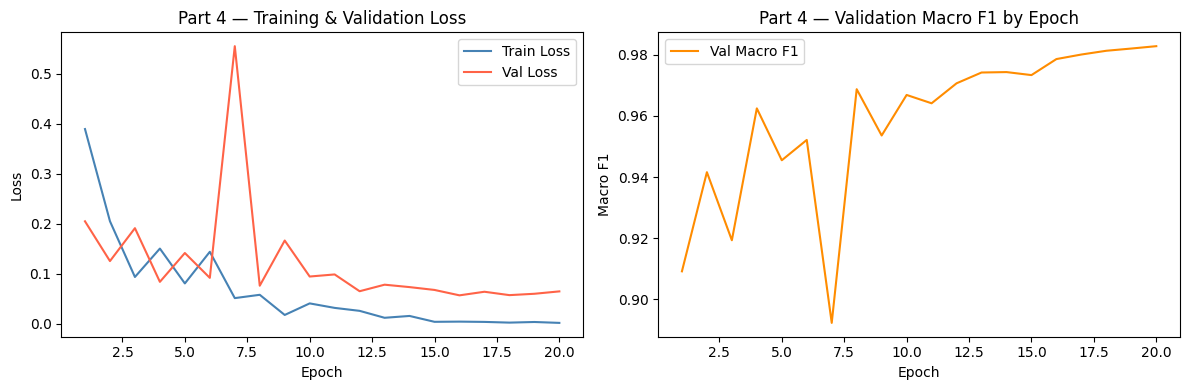

In [ ]:
epochs = range(1, len(hist_p4['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, hist_p4['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs, hist_p4['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Part 4 — Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, hist_p4['val_f1'], color='darkorange', label='Val Macro F1')
axes[1].set_title('Part 4 — Validation Macro F1 by Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('part4_loss_f1_curves.png', dpi=150)
plt.show()

Confusion Matrix

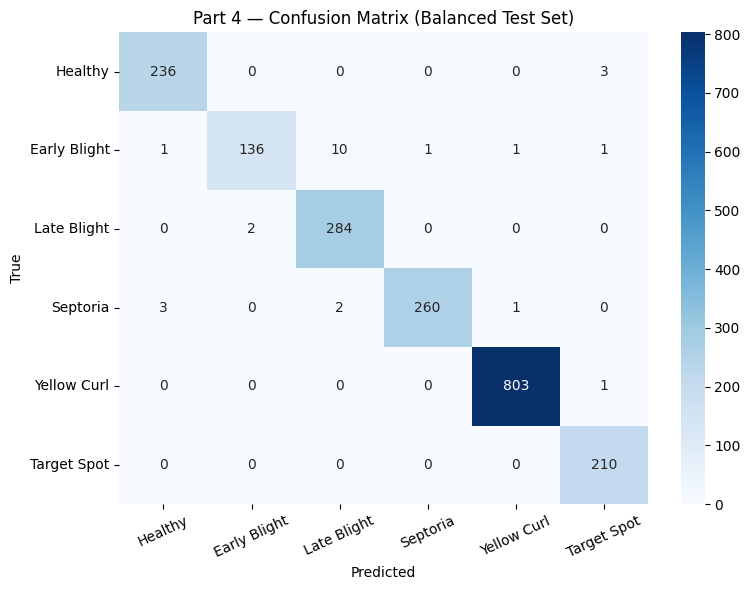

In [ ]:
cm = confusion_matrix(results_balanced['true'], results_balanced['preds'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES, ax=ax)
ax.set_title('Part 4 — Confusion Matrix (Balanced Test Set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('part4_confusion_matrix.png', dpi=150)
plt.show()

Per Class Recall Bar Chart

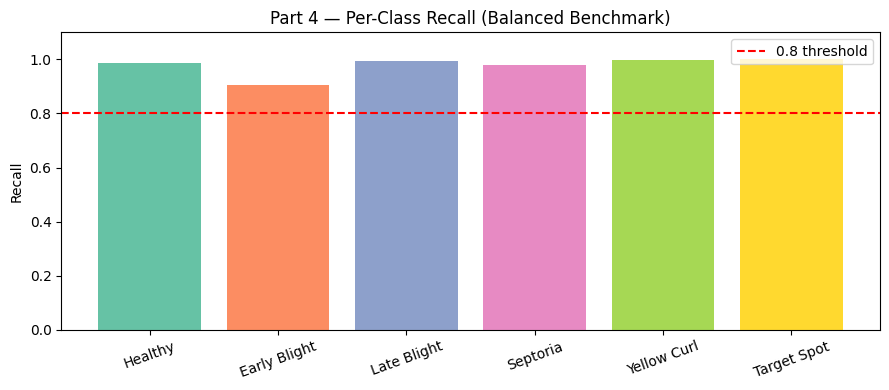

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(SHORT_NAMES, results_balanced['per_class_recall'],
       color=sns.color_palette('Set2', n_cls))
ax.axhline(0.8, color='red', linestyle='--', label='0.8 threshold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Recall')
ax.set_title('Part 4 — Per-Class Recall (Balanced Benchmark)')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('part4_per_class_recall.png', dpi=150)
plt.show()

Imbalanced Datasets (10:1 and 50:1)

In [ ]:
def create_imbalanced_split(train_paths, train_labels, ratio,
                             minority_class_ids, seed=SEED):
    rng          = np.random.default_rng(seed)
    train_labels = np.array(train_labels)
    class_idx    = {c: np.where(train_labels == c)[0].tolist()
                    for c in np.unique(train_labels)}

    # Find the smallest majority class count to use as reference
    majority_ids   = [c for c in class_idx if c not in minority_class_ids]
    majority_count = min(len(class_idx[c]) for c in majority_ids)

    # Target minority count = majority / ratio
    target_min = max(1, majority_count // ratio)

    kept, report = [], []
    for c, idxs in class_idx.items():
        if c in minority_class_ids:
            # Undersample minority
            n      = min(target_min, len(idxs))
            chosen = rng.choice(idxs, size=n, replace=False).tolist()
        else:
            n      = min(majority_count, len(idxs))
            chosen = rng.choice(idxs, size=n, replace=False).tolist()
        kept.extend(chosen)
        report.append({
            'class':             SHORT_NAMES[c],
            'original':          len(idxs),
            'after_undersample': len(chosen),
            'type':              'minority' if c in minority_class_ids else 'majority'
        })

    kept       = sorted(kept)
    paths_out  = [train_paths[i] for i in kept]
    labels_out = train_labels[kept]
    return paths_out, labels_out, pd.DataFrame(report)


MINORITY_IDS = [1, 3]   # Early Blight & Septoria

paths_10, labels_10, report_10 = create_imbalanced_split(
    train_paths_balanced, train_labels_balanced,
    ratio=10, minority_class_ids=MINORITY_IDS
)
paths_50, labels_50, report_50 = create_imbalanced_split(
    train_paths_balanced, train_labels_balanced,
    ratio=50, minority_class_ids=MINORITY_IDS
)

print('=== 10:1 Report ===')
display(report_10)
c10   = Counter(labels_10)
maj10 = max(v for k, v in c10.items() if k not in MINORITY_IDS)
min10 = min(v for k, v in c10.items() if k in MINORITY_IDS)
print(f'Actual ratio : {maj10}:{min10} = {maj10/min10:.1f}:1')

print('\n=== 50:1 Report ===')
display(report_50)
c50   = Counter(labels_50)
maj50 = max(v for k, v in c50.items() if k not in MINORITY_IDS)
min50 = min(v for k, v in c50.items() if k in MINORITY_IDS)
print(f'Actual ratio : {maj50}:{min50} = {maj50/min50:.1f}:1')

=== 10:1 Report ===


,class,original,after_undersample,type
0,Healthy,1114,983,majority
1,Early Blight,700,98,minority
2,Late Blight,1335,983,majority
3,Septoria,1239,98,minority
4,Yellow Curl,3750,983,majority
5,Target Spot,983,983,majority


Actual ratio → 983:98 = 10.0:1

=== 50:1 Report ===


,class,original,after_undersample,type
0,Healthy,1114,983,majority
1,Early Blight,700,19,minority
2,Late Blight,1335,983,majority
3,Septoria,1239,19,minority
4,Yellow Curl,3750,983,majority
5,Target Spot,983,983,majority


Actual ratio → 983:19 = 51.7:1


Bar Chart

/tmp/ipykernel_2804/1634383353.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_2804/1634383353.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_2804/1634383353.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)


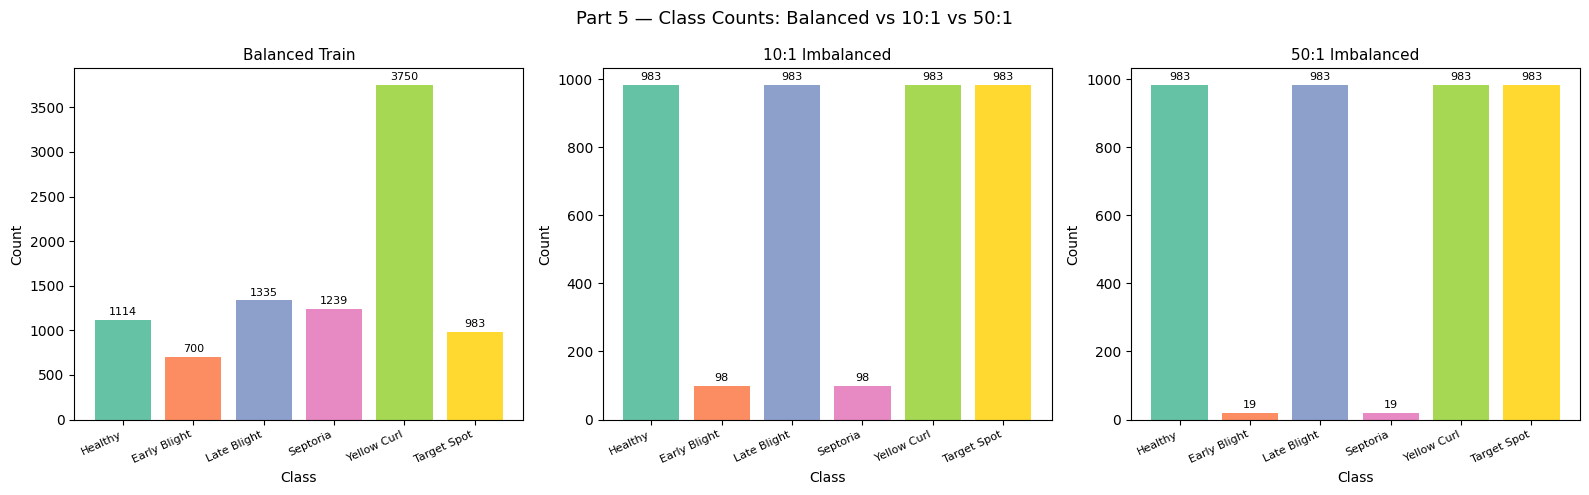

In [ ]:
def class_counts_arr(labels, n):
    c = Counter(np.array(labels))
    return [c.get(i, 0) for i in range(n)]

fig, axes  = plt.subplots(1, 3, figsize=(16, 5))
colors     = sns.color_palette('Set2', n_cls)
titles     = ['Balanced Train', '10:1 Imbalanced', '50:1 Imbalanced']
label_sets = [train_labels_balanced, np.array(labels_10), np.array(labels_50)]

for ax, title, lbls in zip(axes, titles, label_sets):
    counts = class_counts_arr(lbls, n_cls)
    bars   = ax.bar(SHORT_NAMES, counts, color=colors)
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)

fig.suptitle('Part 5 — Class Counts: Balanced vs 10:1 vs 50:1', fontsize=13)
plt.tight_layout()
plt.savefig('part5_imbalance_bar_charts.png', dpi=150)
plt.show()

No Augmentation - 10:1

In [ ]:
loader_6A_10 = make_loader(paths_10, labels_10, train_transform)
model_6A_10  = build_efficientnet()
model_6A_10, hist_6A_10 = train_model(
    model_6A_10, loader_6A_10, val_loader,
    criterion, n_epochs=20, label='6A-NoAug-10:1'
)
res_6A_10 = evaluate(model_6A_10, test_loader, '6A No-Aug 10:1')

[6A-NoAug-10:1] Epoch   1/20 | train=0.6205  val=0.5836  F1=0.7700
[6A-NoAug-10:1] Epoch   5/20 | train=0.0341  val=0.2700  F1=0.9051
[6A-NoAug-10:1] Epoch  10/20 | train=0.0168  val=0.2428  F1=0.9072
[6A-NoAug-10:1] Epoch  15/20 | train=0.0024  val=0.2806  F1=0.9081
[6A-NoAug-10:1] Epoch  20/20 | train=0.0005  val=0.2932  F1=0.9172
[6A-NoAug-10:1] ✅ Best val macro F1 = 0.9172

── 6A No-Aug 10:1 ──────────────────────────────
  Accuracy          : 0.9494
  Macro F1          : 0.9213
  Balanced Accuracy : 0.9189
  Minority Recall   : 0.7200
  Per-class Recall  : [0.9916 0.72   0.9895 0.8158 0.9963 1.    ]


No Augmentation - 50:1

In [ ]:
loader_6A_50 = make_loader(paths_50, labels_50, train_transform)
model_6A_50  = build_efficientnet()
model_6A_50, hist_6A_50 = train_model(
    model_6A_50, loader_6A_50, val_loader,
    criterion, n_epochs=20, label='6A-NoAug-50:1'
)
res_6A_50 = evaluate(model_6A_50, test_loader, '6A No-Aug 50:1')

[6A-NoAug-50:1] Epoch   1/20 | train=0.4729  val=1.3354  F1=0.5444
[6A-NoAug-50:1] Epoch   5/20 | train=0.1659  val=1.1976  F1=0.7214
[6A-NoAug-50:1] Epoch  10/20 | train=0.0642  val=0.7875  F1=0.7895
[6A-NoAug-50:1] Epoch  15/20 | train=0.0112  val=0.8953  F1=0.7681
[6A-NoAug-50:1] Epoch  20/20 | train=0.0149  val=0.8468  F1=0.7440
[6A-NoAug-50:1] ✅ Best val macro F1 = 0.7895

── 6A No-Aug 50:1 ──────────────────────────────
  Accuracy          : 0.8665
  Macro F1          : 0.7842
  Balanced Accuracy : 0.8004
  Minority Recall   : 0.3333
  Per-class Recall  : [0.9874 0.3333 0.9685 0.5489 0.9639 1.    ]


Classical Augmentation - 10:1

In [ ]:
loader_6B_10 = make_loader(
    paths_10, labels_10, train_transform,
    minority_ids=MINORITY_IDS, minority_transform=aug_transform
)
model_6B_10  = build_efficientnet()
model_6B_10, hist_6B_10 = train_model(
    model_6B_10, loader_6B_10, val_loader,
    criterion, n_epochs=20, label='6B-ClassAug-10:1'
)
res_6B_10 = evaluate(model_6B_10, test_loader, '6B ClassAug 10:1')

[6B-ClassAug-10:1] Epoch   1/20 | train=0.4900  val=1.0461  F1=0.6368
[6B-ClassAug-10:1] Epoch   5/20 | train=0.0898  val=1.6122  F1=0.5893
[6B-ClassAug-10:1] Epoch  10/20 | train=0.0282  val=1.4804  F1=0.5807
[6B-ClassAug-10:1] Epoch  15/20 | train=0.0039  val=0.7912  F1=0.7163
[6B-ClassAug-10:1] Epoch  20/20 | train=0.0043  val=0.7854  F1=0.7075
[6B-ClassAug-10:1] ✅ Best val macro F1 = 0.7163

── 6B ClassAug 10:1 ──────────────────────────────
  Accuracy          : 0.8542
  Macro F1          : 0.7195
  Balanced Accuracy : 0.7530
  Minority Recall   : 0.0467
  Per-class Recall  : [0.9958 0.0467 0.9965 0.4812 0.9975 1.    ]


Classical Augmentation - 50:1

In [ ]:
loader_6B_50 = make_loader(
    paths_50, labels_50, train_transform,
    minority_ids=MINORITY_IDS, minority_transform=aug_transform
)
model_6B_50  = build_efficientnet()
model_6B_50, hist_6B_50 = train_model(
    model_6B_50, loader_6B_50, val_loader,
    criterion, n_epochs=20, label='6B-ClassAug-50:1'
)
res_6B_50 = evaluate(model_6B_50, test_loader, '6B ClassAug 50:1')

[6B-ClassAug-50:1] Epoch   1/20 | train=0.4225  val=1.7785  F1=0.5200
[6B-ClassAug-50:1] Epoch   5/20 | train=0.0477  val=2.0580  F1=0.5665
[6B-ClassAug-50:1] Epoch  10/20 | train=0.0161  val=2.3256  F1=0.5651
[6B-ClassAug-50:1] Epoch  15/20 | train=0.0156  val=1.7657  F1=0.5803
[6B-ClassAug-50:1] Epoch  20/20 | train=0.0099  val=1.6577  F1=0.5716
[6B-ClassAug-50:1] ✅ Best val macro F1 = 0.6063

── 6B ClassAug 50:1 ──────────────────────────────
  Accuracy          : 0.7918
  Macro F1          : 0.6015
  Balanced Accuracy : 0.6782
  Minority Recall   : 0.0451
  Per-class Recall  : [0.9833 0.0533 1.     0.0451 0.9925 0.9952]


Oversampling

In [ ]:
def oversample_minority(paths, labels, minority_ids, seed=SEED):
    rng    = np.random.default_rng(seed)
    labels = np.array(labels)
    max_n  = max(Counter(labels).values())

    new_paths, new_lbls = list(paths), list(labels)
    for cls in minority_ids:
        cls_idx = np.where(labels == cls)[0]
        deficit = max_n - len(cls_idx)
        extra   = rng.choice(cls_idx, size=deficit, replace=True)
        new_paths += [paths[i] for i in extra]
        new_lbls  += [cls] * deficit

    return new_paths, np.array(new_lbls)


paths_over_10, labels_over_10 = oversample_minority(paths_10, labels_10, MINORITY_IDS)
paths_over_50, labels_over_50 = oversample_minority(paths_50, labels_50, MINORITY_IDS)

print('Oversampled 10:1 ', Counter(labels_over_10))
print('Oversampled 50:1 ', Counter(labels_over_50))

Oversampled 10:1 → Counter({np.int64(4): 983, np.int64(2): 983, np.int64(5): 983, np.int64(1): 983, np.int64(0): 983, np.int64(3): 983})
Oversampled 50:1 → Counter({np.int64(2): 983, np.int64(5): 983, np.int64(4): 983, np.int64(0): 983, np.int64(1): 983, np.int64(3): 983})


Oversampling - 10:1

In [ ]:
loader_6C_10 = make_loader(paths_over_10, labels_over_10, train_transform)
model_6C_10  = build_efficientnet()
model_6C_10, hist_6C_10 = train_model(
    model_6C_10, loader_6C_10, val_loader,
    criterion, n_epochs=20, label='6C-Oversample-10:1'
)
res_6C_10 = evaluate(model_6C_10, test_loader, '6C Oversample 10:1')

[6C-Oversample-10:1] Epoch   1/20 | train=0.4432  val=0.3536  F1=0.8638
[6C-Oversample-10:1] Epoch   5/20 | train=0.0620  val=0.3808  F1=0.8689
[6C-Oversample-10:1] Epoch  10/20 | train=0.0047  val=0.3656  F1=0.8898
[6C-Oversample-10:1] Epoch  15/20 | train=0.0009  val=0.3083  F1=0.8937
[6C-Oversample-10:1] Epoch  20/20 | train=0.0004  val=0.2981  F1=0.9069
[6C-Oversample-10:1] ✅ Best val macro F1 = 0.9127

── 6C Oversample 10:1 ──────────────────────────────
  Accuracy          : 0.9391
  Macro F1          : 0.9019
  Balanced Accuracy : 0.9008
  Minority Recall   : 0.6467
  Per-class Recall  : [0.9958 0.6467 0.9825 0.7932 0.9963 0.9905]


Oversampling - 50:1

In [ ]:
loader_6C_50 = make_loader(paths_over_50, labels_over_50, train_transform)
model_6C_50  = build_efficientnet()
model_6C_50, hist_6C_50 = train_model(
    model_6C_50, loader_6C_50, val_loader,
    criterion, n_epochs=20, label='6C-Oversample-50:1'
)
res_6C_50 = evaluate(model_6C_50, test_loader, '6C Oversample 50:1')

[6C-Oversample-50:1] Epoch   1/20 | train=0.4212  val=1.9019  F1=0.6270
[6C-Oversample-50:1] Epoch   5/20 | train=0.0221  val=2.1934  F1=0.5749
[6C-Oversample-50:1] Epoch  10/20 | train=0.0062  val=2.0614  F1=0.6234
[6C-Oversample-50:1] Epoch  15/20 | train=0.0014  val=2.1885  F1=0.6269
[6C-Oversample-50:1] Epoch  20/20 | train=0.0004  val=2.1102  F1=0.6174
[6C-Oversample-50:1] ✅ Best val macro F1 = 0.7762

── 6C Oversample 50:1 ──────────────────────────────
  Accuracy          : 0.8542
  Macro F1          : 0.7635
  Balanced Accuracy : 0.7708
  Minority Recall   : 0.2600
  Per-class Recall  : [0.9958 0.26   0.9615 0.5    0.9838 0.9238]


Weighted Loss

In [ ]:
def weighted_criterion(labels, n_classes, device):
    counts  = np.bincount(np.array(labels), minlength=n_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * n_classes
    print('Class weights:', np.round(weights, 4))
    return nn.CrossEntropyLoss(
        weight=torch.tensor(weights, dtype=torch.float32).to(device)
    )

crit_10 = weighted_criterion(labels_10, NUM_CLASSES, DEVICE)
crit_50 = weighted_criterion(labels_50, NUM_CLASSES, DEVICE)

Class weights: [0.2494 2.5013 0.2494 2.5013 0.2494 0.2494]
Class weights: [0.0558 2.8883 0.0558 2.8883 0.0558 0.0558]


Weighted Loss - 10:1

In [ ]:
loader_6D_10 = make_loader(paths_10, labels_10, train_transform)
model_6D_10  = build_efficientnet()
model_6D_10, hist_6D_10 = train_model(
    model_6D_10, loader_6D_10, val_loader,
    crit_10, n_epochs=20, label='6D-WeightedLoss-10:1'
)
res_6D_10 = evaluate(model_6D_10, test_loader, '6D WeightedLoss 10:1')

[6D-WeightedLoss-10:1] Epoch   1/20 | train=1.0672  val=0.5531  F1=0.8550
[6D-WeightedLoss-10:1] Epoch   5/20 | train=0.0772  val=1.1733  F1=0.8401
[6D-WeightedLoss-10:1] Epoch  10/20 | train=0.0129  val=0.7877  F1=0.8924
[6D-WeightedLoss-10:1] Epoch  15/20 | train=0.0017  val=0.7671  F1=0.9123
[6D-WeightedLoss-10:1] Epoch  20/20 | train=0.0048  val=0.7009  F1=0.9157
[6D-WeightedLoss-10:1] ✅ Best val macro F1 = 0.9191

── 6D WeightedLoss 10:1 ──────────────────────────────
  Accuracy          : 0.9545
  Macro F1          : 0.9307
  Balanced Accuracy : 0.9244
  Minority Recall   : 0.7200
  Per-class Recall  : [0.9833 0.72   0.993  0.8571 0.9975 0.9952]


Weighted Loss - 50:1

In [ ]:
loader_6D_50 = make_loader(paths_50, labels_50, train_transform)
model_6D_50  = build_efficientnet()
model_6D_50, hist_6D_50 = train_model(
    model_6D_50, loader_6D_50, val_loader,
    crit_50, n_epochs=20, label='6D-WeightedLoss-50:1'
)
res_6D_50 = evaluate(model_6D_50, test_loader, '6D WeightedLoss 50:1')

[6D-WeightedLoss-50:1] Epoch   1/20 | train=1.3783  val=5.5137  F1=0.5320
[6D-WeightedLoss-50:1] Epoch   5/20 | train=0.3609  val=2.2684  F1=0.6862
[6D-WeightedLoss-50:1] Epoch  10/20 | train=0.0451  val=4.1967  F1=0.7435
[6D-WeightedLoss-50:1] Epoch  15/20 | train=0.0151  val=4.7046  F1=0.7140
[6D-WeightedLoss-50:1] Epoch  20/20 | train=0.0080  val=5.1185  F1=0.7145
[6D-WeightedLoss-50:1] ✅ Best val macro F1 = 0.7767

── 6D WeightedLoss 50:1 ──────────────────────────────
  Accuracy          : 0.8276
  Macro F1          : 0.7694
  Balanced Accuracy : 0.7904
  Minority Recall   : 0.4662
  Per-class Recall  : [0.9916 0.6667 0.7762 0.4662 0.9229 0.919 ]


Summary Table

In [ ]:
def make_row(name, imbalance, res):
    return {
        'Method':            name,
        'Imbalance':         imbalance,
        'Accuracy':          round(res['accuracy'],          4),
        'Macro F1':          round(res['macro_f1'],          4),
        'Minority Recall':   round(res['minority_recall'],   4),
        'Balanced Accuracy': round(res['balanced_accuracy'], 4),
    }

summary = pd.DataFrame([
    make_row('Balanced Benchmark',     'Balanced', results_balanced),
    make_row('No Augmentation',        '10:1',     res_6A_10),
    make_row('No Augmentation',        '50:1',     res_6A_50),
    make_row('Classical Augmentation', '10:1',     res_6B_10),
    make_row('Classical Augmentation', '50:1',     res_6B_50),
    make_row('Oversampling',           '10:1',     res_6C_10),
    make_row('Oversampling',           '50:1',     res_6C_50),
    make_row('Weighted Loss',          '10:1',     res_6D_10),
    make_row('Weighted Loss',          '50:1',     res_6D_50),
])

#print('=== Part 7 — Summary Table ===')
display(summary)

=== Part 7 — Summary Table ===


,Method,Imbalance,Accuracy,Macro F1,Minority Recall,Balanced Accuracy
0,Balanced Benchmark,Balanced,0.9867,0.9798,0.9067,0.9772
1,No Augmentation,10:1,0.9494,0.9213,0.7200,0.9189
2,No Augmentation,50:1,0.8665,0.7842,0.3333,0.8004
3,Classical Augmentation,10:1,0.8542,0.7195,0.0467,0.7530
4,Classical Augmentation,50:1,0.7918,0.6015,0.0451,0.6782
5,Oversampling,10:1,0.9391,0.9019,0.6467,0.9008
6,Oversampling,50:1,0.8542,0.7635,0.2600,0.7708
7,Weighted Loss,10:1,0.9545,0.9307,0.7200,0.9244
8,Weighted Loss,50:1,0.8276,0.7694,0.4662,0.7904


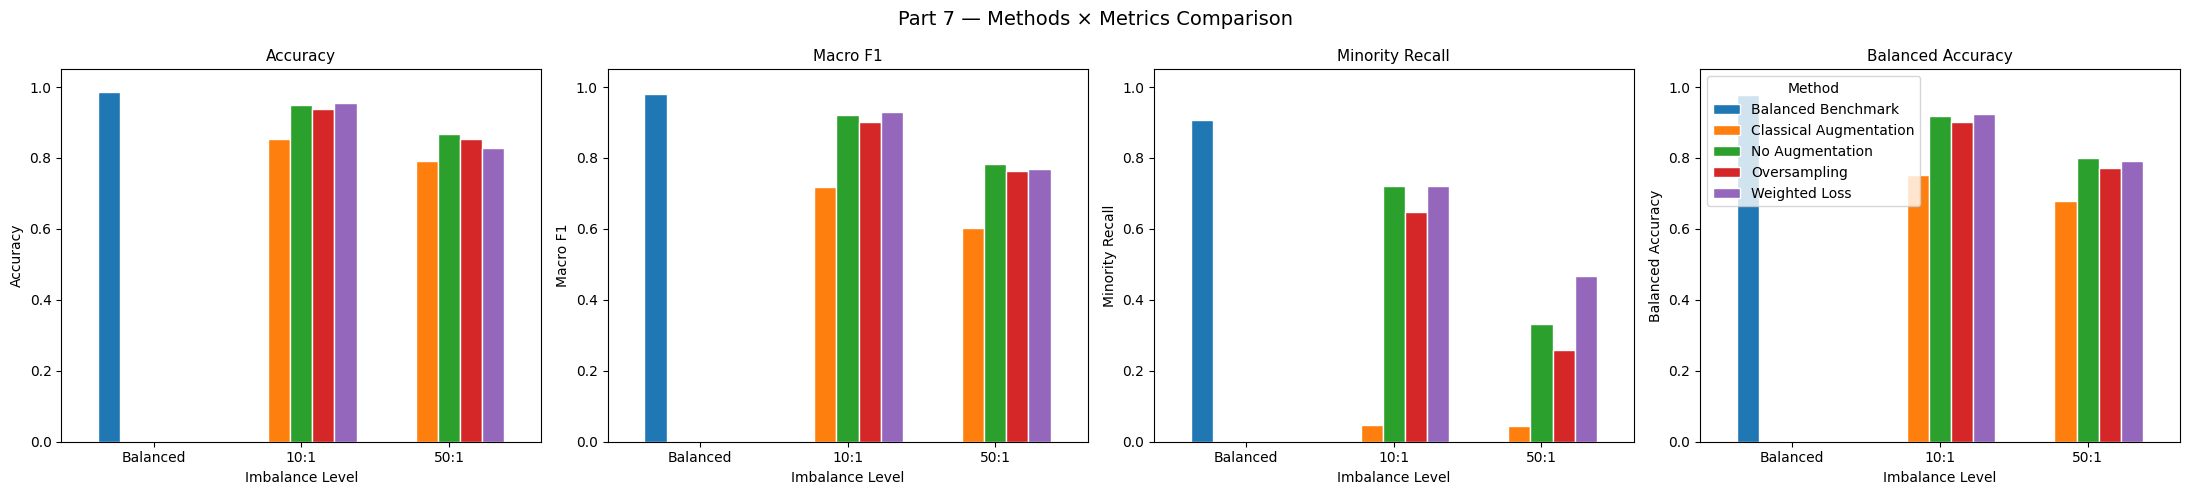

In [ ]:
metrics  = ['Accuracy', 'Macro F1', 'Minority Recall', 'Balanced Accuracy']
imb_lvls = ['Balanced', '10:1', '50:1']
palette  = sns.color_palette('tab10', summary['Method'].nunique())

fig, axes = plt.subplots(1, len(metrics), figsize=(22, 5))

for ax, metric in zip(axes, metrics):
    pivot = summary.pivot(index='Imbalance', columns='Method', values=metric)
    pivot = pivot.reindex(imb_lvls)
    pivot.plot(kind='bar', ax=ax, color=palette,
               legend=(metric == metrics[-1]),
               edgecolor='white', width=0.75)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel('Imbalance Level')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=0)

fig.suptitle('Part 7 — Methods × Metrics Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('part7_grouped_bar_chart.png', dpi=150)
plt.show()

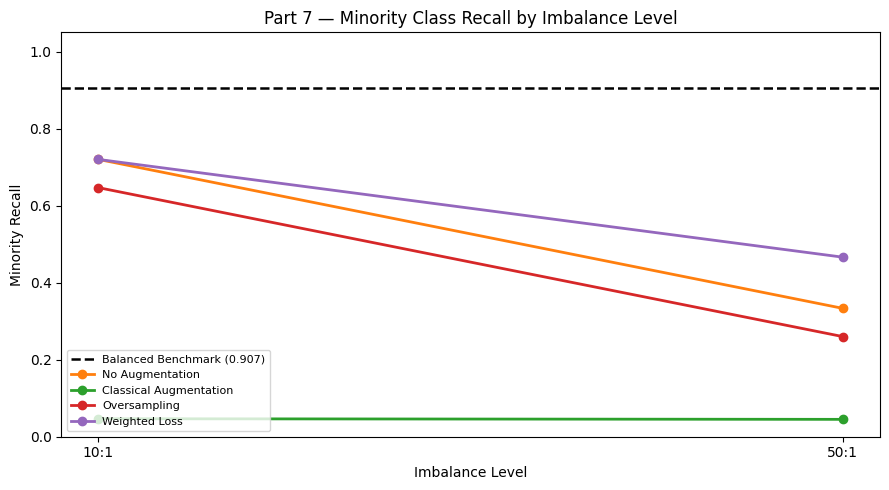

In [ ]:
palette_dict = {m: c for m, c in zip(summary['Method'].unique(), palette)}

fig, ax = plt.subplots(figsize=(9, 5))

for method in summary['Method'].unique():
    sub = summary[summary['Method'] == method]
    if method == 'Balanced Benchmark':
        val = sub['Minority Recall'].values[0]
        ax.axhline(val, color='black', linestyle='--', linewidth=1.8,
                   label=f'Balanced Benchmark ({val:.3f})')
    else:
        ax.plot(sub['Imbalance'], sub['Minority Recall'],
                marker='o', linewidth=2, label=method,
                color=palette_dict[method])

ax.set_title('Part 7 — Minority Class Recall by Imbalance Level')
ax.set_xlabel('Imbalance Level')
ax.set_ylabel('Minority Recall')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig('part7_minority_recall_plot.png', dpi=150)
plt.show()

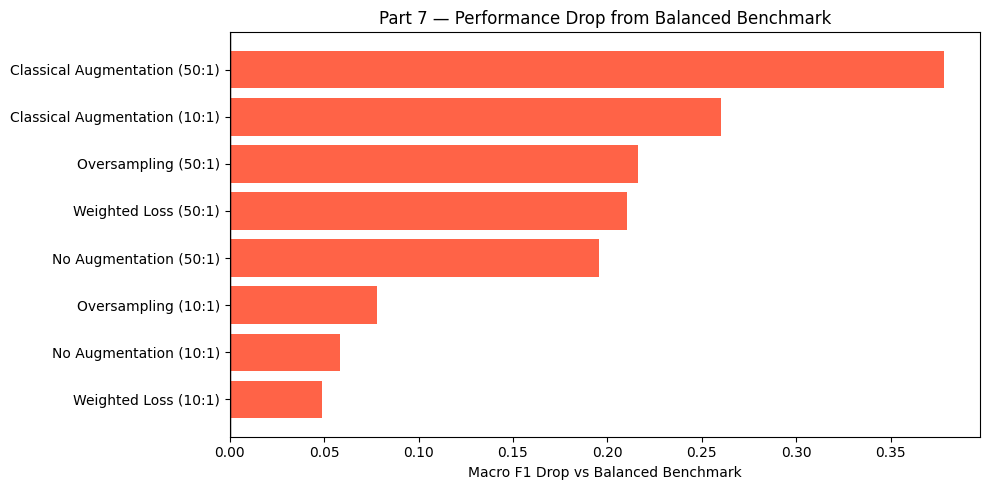


✅ All done!


,Method,Imbalance,Accuracy,Macro F1,Minority Recall,Balanced Accuracy
0,Balanced Benchmark,Balanced,0.9867,0.9798,0.9067,0.9772
1,No Augmentation,10:1,0.9494,0.9213,0.7200,0.9189
2,No Augmentation,50:1,0.8665,0.7842,0.3333,0.8004
3,Classical Augmentation,10:1,0.8542,0.7195,0.0467,0.7530
4,Classical Augmentation,50:1,0.7918,0.6015,0.0451,0.6782
5,Oversampling,10:1,0.9391,0.9019,0.6467,0.9008
6,Oversampling,50:1,0.8542,0.7635,0.2600,0.7708
7,Weighted Loss,10:1,0.9545,0.9307,0.7200,0.9244
8,Weighted Loss,50:1,0.8276,0.7694,0.4662,0.7904


In [ ]:
benchmark_f1     = results_balanced['macro_f1']
drop_df          = summary[summary['Method'] != 'Balanced Benchmark'].copy()
drop_df['Drop']  = benchmark_f1 - drop_df['Macro F1']
drop_df['Label'] = drop_df['Method'] + ' (' + drop_df['Imbalance'] + ')'
drop_df          = drop_df.sort_values('Drop', ascending=True)

colors = ['seagreen' if d <= 0 else 'tomato' for d in drop_df['Drop']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(drop_df['Label'], drop_df['Drop'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Macro F1 Drop vs Balanced Benchmark')
ax.set_title('Part 7 — Performance Drop from Balanced Benchmark')
plt.tight_layout()
plt.savefig('part7_performance_drop.png', dpi=150)
plt.show()

display(summary)

In [ ]:
!pip install -q einops diffusers accelerate

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms as T
# import numpy as np
# import matplotlib.pyplot as plt
# from PIL import Image
# import os
# from tqdm.notebook import tqdm
# from einops import rearrange
# import math

# print('DDPM imports ready.')

DDPM imports ready.


DDPM Config

In [ ]:
# ── Configuration ─────────────────────────────────────────────
DDPM_IMG_SIZE    = 64
DDPM_CHANNELS    = 3
DDPM_TIMESTEPS   = 1000
DDPM_BETA_START  = 1e-4
DDPM_BETA_END    = 0.02
DDPM_EPOCHS      = 200
DDPM_BATCH_SIZE  = 32
DDPM_LR          = 2e-4

# Classes to generate (minority: Early Blight=1, Septoria=3)
MINORITY_IDS     = [1, 3]
MINORITY_NAMES   = ['Early_Blight', 'Septoria']

# How many images to generate per minority class
N_GEN_PER_CLASS  = 500

print(f'DDPM config ready.')
print(f'Image size  : {DDPM_IMG_SIZE}x{DDPM_IMG_SIZE}')
print(f'Timesteps   : {DDPM_TIMESTEPS}')
print(f'Epochs      : {DDPM_EPOCHS}')
print(f'Generate    : {N_GEN_PER_CLASS} images per minority class')

DDPM config ready.
Image size  : 64x64
Timesteps   : 1000
Epochs      : 200
Generate    : 500 images per minority class


Noise Schedule

In [ ]:
def make_noise_schedule(timesteps, beta_start, beta_end):

    betas   = torch.linspace(beta_start, beta_end, timesteps)
    alphas  = 1.0 - betas
    alphas_cumprod       = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev  = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_alphas_cumprod  = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

    posterior_variance = (
        betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    )
    return {
        'betas':                        betas,
        'alphas':                       alphas,
        'alphas_cumprod':               alphas_cumprod,
        'alphas_cumprod_prev':          alphas_cumprod_prev,
        'sqrt_alphas_cumprod':          sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'posterior_variance':           posterior_variance,
    }

schedule = make_noise_schedule(DDPM_TIMESTEPS, DDPM_BETA_START, DDPM_BETA_END)


def to_device(schedule, device):
    return {k: v.to(device) for k, v in schedule.items()}

schedule_gpu = to_device(schedule, DEVICE)
print('Noise schedule created.')

Noise schedule created.


Forward Diffusion

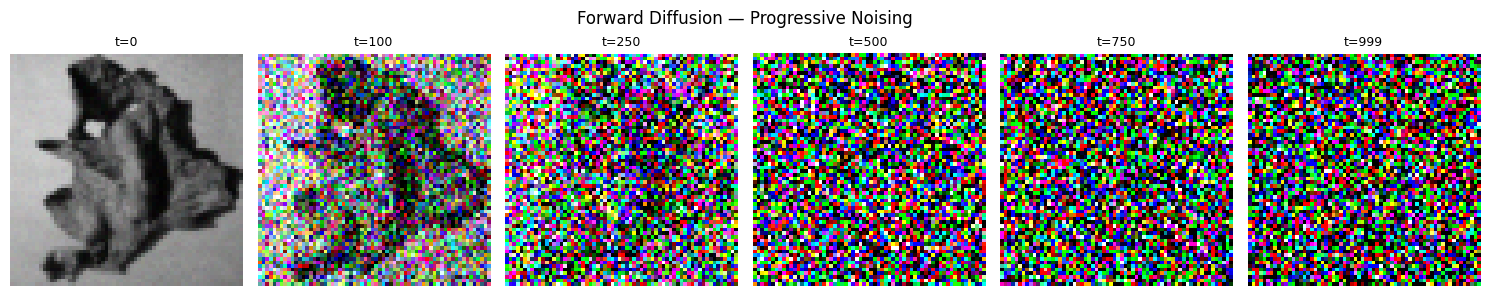

In [ ]:
def q_sample(x0, t, schedule, noise=None):

    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ac  = schedule['sqrt_alphas_cumprod'][t]
    sqrt_omc = schedule['sqrt_one_minus_alphas_cumprod'][t]

    sqrt_ac  = sqrt_ac[:, None, None, None]
    sqrt_omc = sqrt_omc[:, None, None, None]

    return sqrt_ac * x0 + sqrt_omc * noise


def visualize_forward_diffusion(img_path, schedule, steps=[0,100,250,500,750,999]):

    img = Image.open(img_path).convert('RGB')
    tfm = T.Compose([T.Resize((DDPM_IMG_SIZE, DDPM_IMG_SIZE)), T.ToTensor()])
    x0  = tfm(img).unsqueeze(0)

    fig, axes = plt.subplots(1, len(steps), figsize=(len(steps)*2.5, 3))
    for ax, t_val in zip(axes, steps):
        t_tensor = torch.tensor([t_val])
        xt = q_sample(x0, t_tensor, schedule)
        img_np = xt.squeeze(0).permute(1,2,0).clamp(0,1).numpy()
        ax.imshow(img_np)
        ax.set_title(f't={t_val}', fontsize=9)
        ax.axis('off')
    fig.suptitle('Forward Diffusion — Progressive Noising', fontsize=12)
    plt.tight_layout()
    plt.savefig('ddpm_forward_diffusion.png', dpi=150)
    plt.show()

# Visualize using one minority class image
sample_path = [p for p, l in zip(train_paths_balanced,
                                   train_labels_balanced) if l == 1][0]
visualize_forward_diffusion(sample_path, schedule)

UNet Building Blocks

In [ ]:
# ── Sinusoidal time embedding ─────────────────────────────────
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        emb    = math.log(10000) / (half - 1)
        emb    = torch.exp(torch.arange(half, device=device) * -emb)
        emb    = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


# ── Residual block ────────────────────────────────────────────
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, num_classes=None):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(
            nn.SiLU(), nn.Linear(time_dim, out_ch)
        )
        # Class conditioning
        self.class_emb = (
            nn.Embedding(num_classes, out_ch) if num_classes else None
        )
        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x, t_emb, c=None):
        h = self.conv1(F.silu(self.norm1(x)))
        # Add time embedding
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        # Add class embedding
        if self.class_emb is not None and c is not None:
            h = h + self.class_emb(c)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# ── Attention block ───────────────────────────────────────────
class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm  = nn.GroupNorm(8, ch)
        self.qkv   = nn.Conv2d(ch, ch * 3, 1)
        self.proj  = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h          = self.norm(x)
        qkv        = self.qkv(h).reshape(B, 3, C, H*W)
        q, k, v    = qkv.unbind(1)
        scale      = C ** -0.5
        attn       = torch.softmax(q.transpose(-1,-2) @ k * scale, dim=-1)
        out        = (attn @ v.transpose(-1,-2)).transpose(-1,-2)
        return x + self.proj(out.reshape(B, C, H, W))


print('UNet building blocks defined.')

UNet building blocks defined.


UNet Architecture

In [ ]:
class UNet(nn.Module):

    def __init__(self, img_channels=3, base_dim=64, num_classes=None):
        super().__init__()
        time_dim = base_dim * 4
        dims     = [base_dim, base_dim*2, base_dim*4, base_dim*8]

        # ── Time embedding MLP ──────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(base_dim),
            nn.Linear(base_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # ── Encoder ─────────────────────────────────────────
        self.enc_in  = nn.Conv2d(img_channels, dims[0], 3, padding=1)
        self.enc0    = ResBlock(dims[0], dims[0], time_dim, num_classes)
        self.down0   = nn.Conv2d(dims[0], dims[0], 4, 2, 1)   # 64->32

        self.enc1    = ResBlock(dims[0], dims[1], time_dim, num_classes)
        self.down1   = nn.Conv2d(dims[1], dims[1], 4, 2, 1)   # 32->16

        self.enc2    = ResBlock(dims[1], dims[2], time_dim, num_classes)
        self.down2   = nn.Conv2d(dims[2], dims[2], 4, 2, 1)   # 16->8

        # ── Bottleneck ───────────────────────────────────────
        self.mid0    = ResBlock(dims[2], dims[3], time_dim, num_classes)
        self.attn    = SelfAttention(dims[3])
        self.mid1    = ResBlock(dims[3], dims[3], time_dim, num_classes)

        # ── Decoder ─────────────────────────────────────────
        self.up2     = nn.ConvTranspose2d(dims[3], dims[2], 4, 2, 1)  # 8->16
        self.dec2    = ResBlock(dims[2]*2, dims[2], time_dim, num_classes)

        self.up1     = nn.ConvTranspose2d(dims[2], dims[1], 4, 2, 1)  # 16->32
        self.dec1    = ResBlock(dims[1]*2, dims[1], time_dim, num_classes)

        self.up0     = nn.ConvTranspose2d(dims[1], dims[0], 4, 2, 1)  # 32->64
        self.dec0    = ResBlock(dims[0]*2, dims[0], time_dim, num_classes)

        # ── Output ──────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, dims[0])
        self.out_conv = nn.Conv2d(dims[0], img_channels, 1)

    def forward(self, x, t, c=None):
        t_emb = self.time_mlp(t)

        # Encoder
        x0 = self.enc0(self.enc_in(x), t_emb, c)     # (B, 64, 64, 64)
        x1 = self.enc1(self.down0(x0), t_emb, c)     # (B,128, 32, 32)
        x2 = self.enc2(self.down1(x1), t_emb, c)     # (B,256, 16, 16)

        # Bottleneck
        xm = self.mid0(self.down2(x2), t_emb, c)     # (B,512,  8,  8)
        xm = self.mid1(self.attn(xm),  t_emb, c)

        # Decoder with skip connections
        xd = self.dec2(
            torch.cat([self.up2(xm), x2], dim=1), t_emb, c)
        xd = self.dec1(
            torch.cat([self.up1(xd), x1], dim=1), t_emb, c)
        xd = self.dec0(
            torch.cat([self.up0(xd), x0], dim=1), t_emb, c)

        return self.out_conv(F.silu(self.out_norm(xd)))



_model = UNet(img_channels=3, base_dim=64, num_classes=2).to(DEVICE)
_x = torch.randn(2, 3, DDPM_IMG_SIZE, DDPM_IMG_SIZE).to(DEVICE)
_t = torch.randint(0, DDPM_TIMESTEPS, (2,)).to(DEVICE)
_c = torch.tensor([0, 1]).to(DEVICE)
_out = _model(_x, _t, _c)
print(f'UNet output shape: {_out.shape}')   # expect (2, 3, 64, 64)
del _model, _x, _t, _c, _out

UNet output shape: torch.Size([2, 3, 64, 64])


DDPM Dataset

In [ ]:
class DDPMDataset(Dataset):

    def __init__(self, paths, labels, class_ids, img_size=DDPM_IMG_SIZE):
        # Filter to selected classes only
        self.data = [
            (p, class_ids.index(l))
            for p, l in zip(paths, labels)
            if l in class_ids
        ]
        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Lambda(lambda x: x * 2 - 1)   # scale to [-1, 1]
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label


ddpm_dataset = DDPMDataset(
    train_paths_balanced,
    train_labels_balanced,
    class_ids=MINORITY_IDS
)
ddpm_loader = DataLoader(
    ddpm_dataset, batch_size=DDPM_BATCH_SIZE,
    shuffle=True, num_workers=2, drop_last=True
)

print(f'DDPM dataset size : {len(ddpm_dataset)} images')
print(f'Classes           : {[SHORT_NAMES[i] for i in MINORITY_IDS]}')
print(f'Batches per epoch : {len(ddpm_loader)}')

DDPM dataset size : 1939 images
Classes           : ['Early Blight', 'Septoria']
Batches per epoch : 60


DDPM Training Loop

In [ ]:
def train_ddpm(model, loader, schedule, n_epochs, lr, label='DDPM'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs
    )
    losses = []

    model.train()
    for epoch in range(1, n_epochs + 1):
        epoch_loss = 0.0
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)       # (B, 3, H, W) in [-1,1]
            labels = labels.to(DEVICE)     # (B,) re-indexed

            # Random timesteps
            t = torch.randint(0, DDPM_TIMESTEPS, (imgs.size(0),),
                              device=DEVICE)
            # Sample noise
            noise = torch.randn_like(imgs)
            # Forward diffusion
            x_t   = q_sample(imgs, t, schedule_gpu, noise)
            # Predict noise with UNet
            pred  = model(x_t, t, labels)
            # MSE loss between predicted and actual noise
            loss  = F.mse_loss(pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)

        if epoch % 20 == 0 or epoch == 1:
            print(f'[{label}] Epoch {epoch:3d}/{n_epochs} | loss={avg_loss:.5f}')

    return losses


# Build model and train
ddpm_model = UNet(
    img_channels=DDPM_CHANNELS,
    base_dim=64,
    num_classes=len(MINORITY_IDS)   # 2 classes
).to(DEVICE)

total_params = sum(p.numel() for p in ddpm_model.parameters())
print(f'UNet parameters: {total_params:,}')
#print(f'\nStarting DDPM training for {DDPM_EPOCHS} epochs...')

ddpm_losses = train_ddpm(
    ddpm_model, ddpm_loader, schedule_gpu,
    n_epochs=DDPM_EPOCHS, lr=DDPM_LR
)

UNet parameters: 17,879,683

Starting DDPM training for 200 epochs...
[DDPM] Epoch   1/200 | loss=0.29324
[DDPM] Epoch  20/200 | loss=0.01933
[DDPM] Epoch  40/200 | loss=0.01530
[DDPM] Epoch  60/200 | loss=0.01650
[DDPM] Epoch  80/200 | loss=0.01571
[DDPM] Epoch 100/200 | loss=0.01390
[DDPM] Epoch 120/200 | loss=0.01357
[DDPM] Epoch 140/200 | loss=0.01499
[DDPM] Epoch 160/200 | loss=0.01341
[DDPM] Epoch 180/200 | loss=0.01247
[DDPM] Epoch 200/200 | loss=0.01425


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = '/content/drive/MyDrive/plantvillage_ddpm'
os.makedirs(CKPT_DIR, exist_ok=True)

ckpt_path = os.path.join(CKPT_DIR, 'ddpm_unet.pt')
torch.save({
    'model_state_dict': ddpm_model.state_dict(),
    'losses':           ddpm_losses,
    'config': {
        'img_size':    DDPM_IMG_SIZE,
        'channels':    DDPM_CHANNELS,
        'timesteps':   DDPM_TIMESTEPS,
        'minority_ids': MINORITY_IDS,
    }
}, ckpt_path)

print(f'Checkpoint saved to: {ckpt_path}')

Mounted at /content/drive
✅ Checkpoint saved to: /content/drive/MyDrive/plantvillage_ddpm/ddpm_unet.pt


Plot DDPM Training Loss

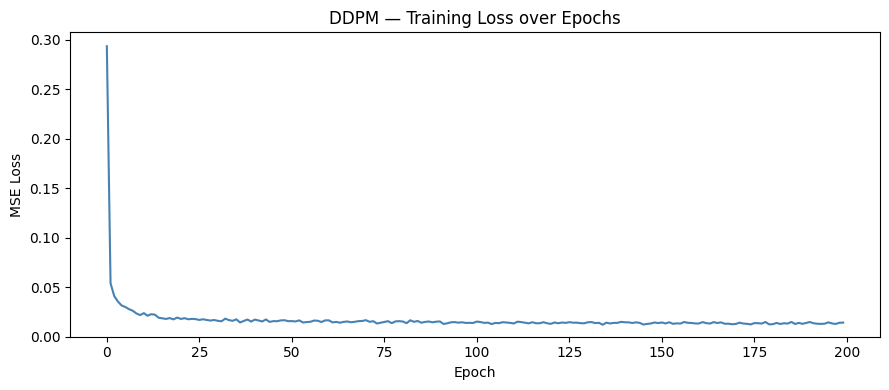

Final loss: 0.01425


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ddpm_losses, color='steelblue', linewidth=1.5)
ax.set_title('DDPM — Training Loss over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('ddpm_training_loss.png', dpi=150)
plt.show()
print(f'Final loss: {ddpm_losses[-1]:.5f}')

DDPM Sampling

In [ ]:
@torch.no_grad()
def p_sample(model, x, t_val, schedule, class_label):
    model.eval()
    t_tensor = torch.full((x.size(0),), t_val,
                           device=DEVICE, dtype=torch.long)

    # Predict noise
    pred_noise = model(x, t_tensor, class_label)

    # Extract schedule values
    beta        = schedule['betas'][t_val]
    alpha       = schedule['alphas'][t_val]
    alpha_cp    = schedule['alphas_cumprod'][t_val]
    sqrt_omc    = schedule['sqrt_one_minus_alphas_cumprod'][t_val]

    # Compute predicted x0
    pred_x0 = (x - sqrt_omc * pred_noise) / torch.sqrt(alpha_cp)
    pred_x0 = pred_x0.clamp(-1, 1)

    # Compute mean of posterior
    coef1 = beta * torch.sqrt(schedule['alphas_cumprod_prev'][t_val]) \
            / (1 - alpha_cp)
    coef2 = (1 - schedule['alphas_cumprod_prev'][t_val]) \
            * torch.sqrt(alpha) / (1 - alpha_cp)
    mean  = coef1 * pred_x0 + coef2 * x

    if t_val == 0:
        return mean
    else:
        noise = torch.randn_like(x)
        std   = torch.sqrt(schedule['posterior_variance'][t_val])
        return mean + std * noise


@torch.no_grad()
def generate_images(model, schedule, n_images, class_idx,
                    img_size=DDPM_IMG_SIZE):

    model.eval()
    x = torch.randn(n_images, 3, img_size, img_size).to(DEVICE)
    c = torch.full((n_images,), class_idx,
                   dtype=torch.long, device=DEVICE)

    for t in tqdm(reversed(range(DDPM_TIMESTEPS)),
                  total=DDPM_TIMESTEPS, desc=f'Sampling class {class_idx}',
                  leave=False):
        x = p_sample(model, x, t, schedule_gpu, c)

    return x   # in [-1, 1]


def tensor_to_pil(t):
    arr = ((t.clamp(-1,1) + 1) / 2 * 255).byte()
    return Image.fromarray(arr.permute(1,2,0).cpu().numpy())


print('Sampling functions defined.')

Sampling functions defined.


Sampling class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

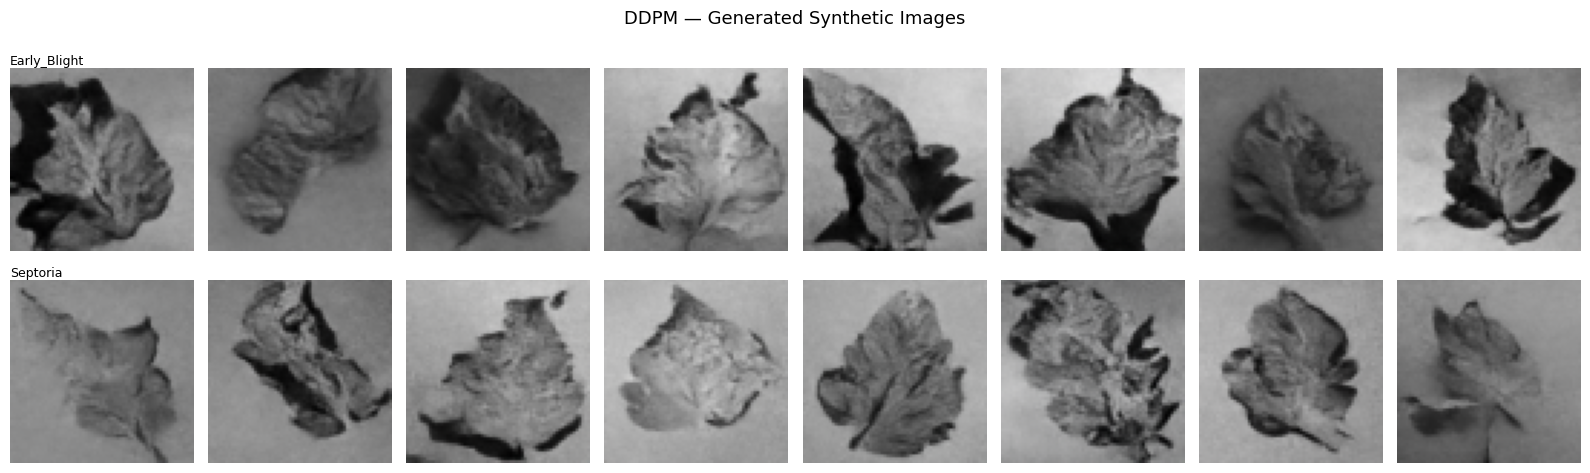

In [ ]:
# Generate a small batch to visually check quality first
N_PREVIEW = 8

fig, axes = plt.subplots(
    len(MINORITY_IDS), N_PREVIEW,
    figsize=(N_PREVIEW * 2, len(MINORITY_IDS) * 2.5)
)

for row, (cls_idx, cls_name) in enumerate(
        zip(range(len(MINORITY_IDS)), MINORITY_NAMES)):

    samples = generate_images(ddpm_model, schedule_gpu,
                               n_images=N_PREVIEW, class_idx=cls_idx)
    for col in range(N_PREVIEW):
        img_np = ((samples[col].clamp(-1,1) + 1) / 2)
        img_np = img_np.permute(1,2,0).cpu().numpy()
        axes[row, col].imshow(img_np)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls_name, fontsize=9,
                                      loc='left', pad=3)

fig.suptitle('DDPM — Generated Synthetic Images', fontsize=13)
plt.tight_layout()
plt.savefig('ddpm_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Generate Full Synthetic Dataset

In [ ]:
GEN_DIR = '/content/drive/MyDrive/plantvillage_ddpm/generated'
os.makedirs(GEN_DIR, exist_ok=True)

BATCH_GEN  = 50
all_gen_paths  = []
all_gen_labels = []

for cls_idx, (orig_label, cls_name) in enumerate(
        zip(MINORITY_IDS, MINORITY_NAMES)):

    cls_dir = os.path.join(GEN_DIR, cls_name)
    os.makedirs(cls_dir, exist_ok=True)

    n_batches = math.ceil(N_GEN_PER_CLASS / BATCH_GEN)
    saved     = 0

    print(f'Generating {N_GEN_PER_CLASS} images for {cls_name}...')
    for b in tqdm(range(n_batches)):
        n_this = min(BATCH_GEN, N_GEN_PER_CLASS - saved)
        imgs   = generate_images(ddpm_model, schedule_gpu,
                                  n_images=n_this, class_idx=cls_idx)
        for i in range(n_this):
            pil_img = tensor_to_pil(imgs[i])
            save_path = os.path.join(cls_dir, f'syn_{saved:04d}.png')
            pil_img.save(save_path)
            all_gen_paths.append(save_path)
            all_gen_labels.append(orig_label)   # original label index
            saved += 1

    #print(f'  Saved {saved} images for {cls_name}')

all_gen_labels = np.array(all_gen_labels)
print(f'\nTotal synthetic images : {len(all_gen_paths)}')
print(f'Label distribution     : {Counter(all_gen_labels)}')

Generating 500 images for Early_Blight...


  0%|          | 0/10 [00:00<?, ?it/s]

Sampling class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 0:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Sampling class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling class 1:   0%|          | 0/1000 [00:00<?, ?it/s]

  ✅ Saved 500 images for Septoria

Total synthetic images : 1000
Label distribution     : Counter({np.int64(1): 500, np.int64(3): 500})


Augment Imbalanced Sets with Synthetic Images

In [ ]:
def augment_with_synthetic(real_paths, real_labels,
                             syn_paths, syn_labels):

    combined_paths  = list(real_paths) + list(syn_paths)
    combined_labels = np.concatenate([
        np.array(real_labels), np.array(syn_labels)
    ])
    return combined_paths, combined_labels


# Augment 10:1 and 50:1 sets
paths_ddpm_10, labels_ddpm_10 = augment_with_synthetic(
    paths_10, labels_10, all_gen_paths, all_gen_labels
)
paths_ddpm_50, labels_ddpm_50 = augment_with_synthetic(
    paths_50, labels_50, all_gen_paths, all_gen_labels
)

print(f'10:1 set: {Counter(labels_ddpm_10)}')
print(f'50:1 set: {Counter(labels_ddpm_50)}')

=== After DDPM Augmentation ===
10:1 set: Counter({np.int64(4): 983, np.int64(2): 983, np.int64(5): 983, np.int64(0): 983, np.int64(1): 598, np.int64(3): 598})
50:1 set: Counter({np.int64(2): 983, np.int64(5): 983, np.int64(4): 983, np.int64(0): 983, np.int64(1): 519, np.int64(3): 519})


Before vs After DDPM Augmentation

/tmp/ipykernel_2804/4174406413.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_2804/4174406413.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_2804/4174406413.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_2804/4174406413.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)


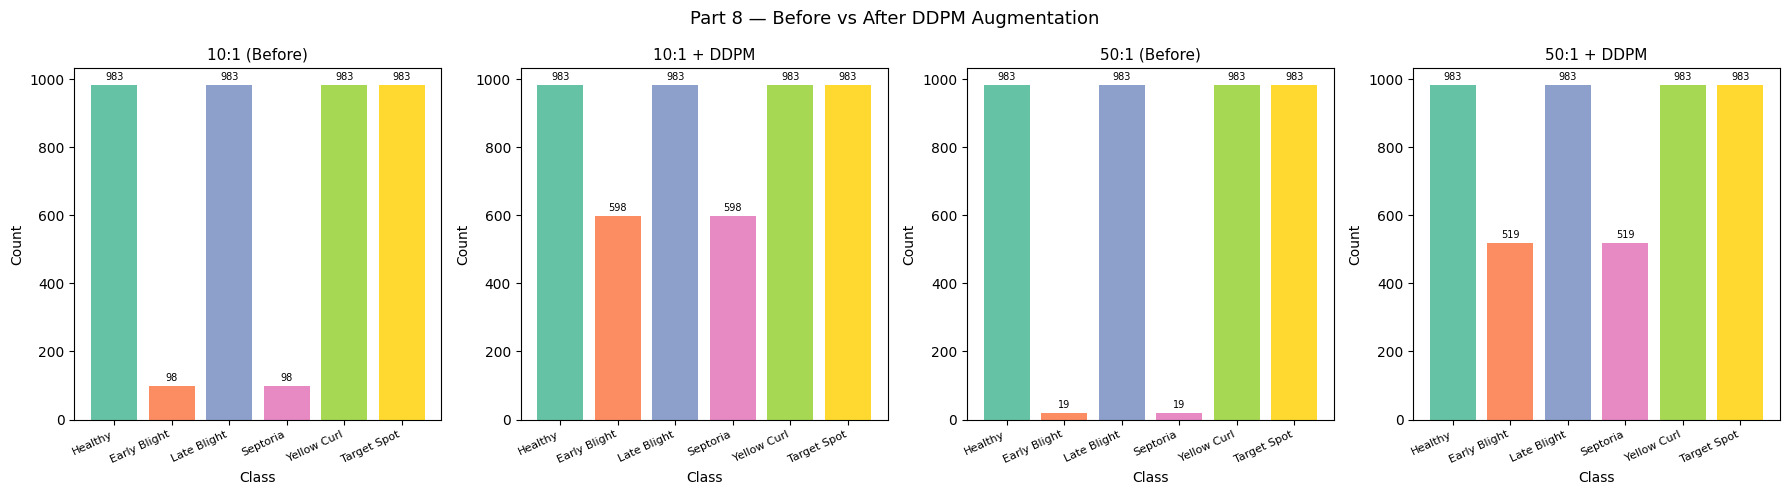

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = sns.color_palette('Set2', n_cls)
titles = ['10:1 (Before)', '10:1 + DDPM', '50:1 (Before)', '50:1 + DDPM']
label_sets = [
    np.array(labels_10), np.array(labels_ddpm_10),
    np.array(labels_50), np.array(labels_ddpm_50)
]

for ax, title, lbls in zip(axes, titles, label_sets):
    counts = class_counts_arr(lbls, n_cls)
    bars   = ax.bar(SHORT_NAMES, counts, color=colors)
    ax.bar_label(bars, padding=2, fontsize=7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticklabels(SHORT_NAMES, rotation=25, ha='right', fontsize=8)

fig.suptitle('Part 8 — Before vs After DDPM Augmentation', fontsize=13)
plt.tight_layout()
plt.savefig('part8_ddpm_augmentation_counts.png', dpi=150)
plt.show()

Train DDPM-Augmented Classifier — 10:1

In [ ]:
loader_ddpm_10 = make_loader(paths_ddpm_10, labels_ddpm_10, train_transform)
model_ddpm_10  = build_efficientnet()
model_ddpm_10, hist_ddpm_10 = train_model(
    model_ddpm_10, loader_ddpm_10, val_loader,
    criterion, n_epochs=20, label='DDPM-Aug-10:1'
)
res_ddpm_10 = evaluate(model_ddpm_10, test_loader, 'DDPM Augmented 10:1')

[DDPM-Aug-10:1] Epoch   1/20 | train=0.5619  val=1.0762  F1=0.6945
[DDPM-Aug-10:1] Epoch   5/20 | train=0.0724  val=0.5094  F1=0.8174
[DDPM-Aug-10:1] Epoch  10/20 | train=0.0397  val=0.2679  F1=0.9038
[DDPM-Aug-10:1] Epoch  15/20 | train=0.0074  val=0.2460  F1=0.9120
[DDPM-Aug-10:1] Epoch  20/20 | train=0.0013  val=0.2787  F1=0.9085
[DDPM-Aug-10:1] ✅ Best val macro F1 = 0.9208

── DDPM Augmented 10:1 ──────────────────────────────
  Accuracy          : 0.9427
  Macro F1          : 0.9120
  Balanced Accuracy : 0.9093
  Minority Recall   : 0.7000
  Per-class Recall  : [0.9958 0.7    0.9895 0.7744 0.9963 1.    ]


Train DDPM-Augmented Classifier — 50:1

In [ ]:
loader_ddpm_50 = make_loader(paths_ddpm_50, labels_ddpm_50, train_transform)
model_ddpm_50  = build_efficientnet()
model_ddpm_50, hist_ddpm_50 = train_model(
    model_ddpm_50, loader_ddpm_50, val_loader,
    criterion, n_epochs=20, label='DDPM-Aug-50:1'
)
res_ddpm_50 = evaluate(model_ddpm_50, test_loader, 'DDPM Augmented 50:1')

[DDPM-Aug-50:1] Epoch   1/20 | train=0.5529  val=0.5539  F1=0.7598
[DDPM-Aug-50:1] Epoch   5/20 | train=0.1107  val=0.9787  F1=0.6740
[DDPM-Aug-50:1] Epoch  10/20 | train=0.0279  val=1.0670  F1=0.7271
[DDPM-Aug-50:1] Epoch  15/20 | train=0.0023  val=0.9118  F1=0.7605
[DDPM-Aug-50:1] Epoch  20/20 | train=0.0003  val=0.9488  F1=0.7605
[DDPM-Aug-50:1] ✅ Best val macro F1 = 0.8077

── DDPM Augmented 50:1 ──────────────────────────────
  Accuracy          : 0.8916
  Macro F1          : 0.8222
  Balanced Accuracy : 0.8264
  Minority Recall   : 0.4267
  Per-class Recall  : [0.9916 0.4267 0.979  0.5789 0.9963 0.9857]


Training on Synthetic Data

In [ ]:


def build_synthetic_only_set(real_paths, real_labels,
                              syn_paths, syn_labels,
                              minority_ids, ratio=10):

    rng = np.random.default_rng(SEED)

    majority_paths  = [p for p, l in zip(real_paths, real_labels)
                       if l not in minority_ids]
    majority_labels = [l for l in real_labels if l not in minority_ids]

    syn_paths  = list(syn_paths)
    syn_labels = list(syn_labels)

    combined_paths  = majority_paths  + syn_paths
    combined_labels = majority_labels + syn_labels

    return combined_paths, np.array(combined_labels)


paths_syn_only_10, labels_syn_only_10 = build_synthetic_only_set(
    paths_10, labels_10,
    all_gen_paths, all_gen_labels,
    minority_ids=MINORITY_IDS
)
paths_syn_only_50, labels_syn_only_50 = build_synthetic_only_set(
    paths_50, labels_50,
    all_gen_paths, all_gen_labels,
    minority_ids=MINORITY_IDS
)

print('=== Synthetic-Only Training Sets ===')
print(f'10:1 synthetic-only: {Counter(labels_syn_only_10)}')
print(f'50:1 synthetic-only: {Counter(labels_syn_only_50)}')

=== Synthetic-Only Training Sets ===
10:1 synthetic-only: Counter({np.int64(4): 983, np.int64(2): 983, np.int64(5): 983, np.int64(0): 983, np.int64(1): 500, np.int64(3): 500})
50:1 synthetic-only: Counter({np.int64(2): 983, np.int64(5): 983, np.int64(4): 983, np.int64(0): 983, np.int64(1): 500, np.int64(3): 500})


Train on Synthetic Only — 10:1

In [ ]:
loader_syn_10 = make_loader(paths_syn_only_10, labels_syn_only_10,
                             train_transform)
model_syn_10  = build_efficientnet()
model_syn_10, hist_syn_10 = train_model(
    model_syn_10, loader_syn_10, val_loader,
    criterion, n_epochs=20, label='SynOnly-10:1'
)
res_syn_10 = evaluate(model_syn_10, test_loader, 'Synthetic Only 10:1')

[SynOnly-10:1] Epoch   1/20 | train=0.4653  val=2.7848  F1=0.5449
[SynOnly-10:1] Epoch   5/20 | train=0.0619  val=2.2364  F1=0.5980
[SynOnly-10:1] Epoch  10/20 | train=0.0570  val=2.6140  F1=0.5715
[SynOnly-10:1] Epoch  15/20 | train=0.0097  val=2.4268  F1=0.5806
[SynOnly-10:1] Epoch  20/20 | train=0.0015  val=2.6103  F1=0.5774
[SynOnly-10:1] ✅ Best val macro F1 = 0.5980

── Synthetic Only 10:1 ──────────────────────────────
  Accuracy          : 0.7908
  Macro F1          : 0.5903
  Balanced Accuracy : 0.6733
  Minority Recall   : 0.0000
  Per-class Recall  : [0.9916 0.     0.993  0.0677 0.9925 0.9952]


 Train on Synthetic Only — 50:1

In [ ]:
loader_syn_50 = make_loader(paths_syn_only_50, labels_syn_only_50,
                             train_transform)
model_syn_50  = build_efficientnet()
model_syn_50, hist_syn_50 = train_model(
    model_syn_50, loader_syn_50, val_loader,
    criterion, n_epochs=20, label='SynOnly-50:1'
)
res_syn_50 = evaluate(model_syn_50, test_loader, 'Synthetic Only 50:1')

[SynOnly-50:1] Epoch   1/20 | train=0.5089  val=2.4295  F1=0.5624
[SynOnly-50:1] Epoch   5/20 | train=0.0331  val=2.6548  F1=0.5744
[SynOnly-50:1] Epoch  10/20 | train=0.0095  val=2.3124  F1=0.5710
[SynOnly-50:1] Epoch  15/20 | train=0.0110  val=2.5829  F1=0.5712
[SynOnly-50:1] Epoch  20/20 | train=0.0034  val=3.5162  F1=0.5726
[SynOnly-50:1] ✅ Best val macro F1 = 0.6208

── Synthetic Only 50:1 ──────────────────────────────
  Accuracy          : 0.7969
  Macro F1          : 0.6155
  Balanced Accuracy : 0.6812
  Minority Recall   : 0.0267
  Per-class Recall  : [0.9833 0.0267 0.993  0.0977 0.9963 0.9905]


Full Summary Table

In [ ]:
summary_full = pd.DataFrame([
    make_row('Balanced Benchmark',     'Balanced', results_balanced),
    make_row('No Augmentation',        '10:1',     res_6A_10),
    make_row('No Augmentation',        '50:1',     res_6A_50),
    make_row('Classical Augmentation', '10:1',     res_6B_10),
    make_row('Classical Augmentation', '50:1',     res_6B_50),
    make_row('Oversampling',           '10:1',     res_6C_10),
    make_row('Oversampling',           '50:1',     res_6C_50),
    make_row('Weighted Loss',          '10:1',     res_6D_10),
    make_row('Weighted Loss',          '50:1',     res_6D_50),
    make_row('DDPM Aug (Real+Syn)',    '10:1',     res_ddpm_10),
    make_row('DDPM Aug (Real+Syn)',    '50:1',     res_ddpm_50),
    make_row('Synthetic Only',         '10:1',     res_syn_10),
    make_row('Synthetic Only',         '50:1',     res_syn_50),
])

display(summary_full)

=== Full Summary Table (All Methods) ===


,Method,Imbalance,Accuracy,Macro F1,Minority Recall,Balanced Accuracy
0,Balanced Benchmark,Balanced,0.9867,0.9798,0.9067,0.9772
1,No Augmentation,10:1,0.9494,0.9213,0.7200,0.9189
2,No Augmentation,50:1,0.8665,0.7842,0.3333,0.8004
3,Classical Augmentation,10:1,0.8542,0.7195,0.0467,0.7530
4,Classical Augmentation,50:1,0.7918,0.6015,0.0451,0.6782
5,Oversampling,10:1,0.9391,0.9019,0.6467,0.9008
6,Oversampling,50:1,0.8542,0.7635,0.2600,0.7708
7,Weighted Loss,10:1,0.9545,0.9307,0.7200,0.9244
8,Weighted Loss,50:1,0.8276,0.7694,0.4662,0.7904
9,DDPM Aug (Real+Syn),10:1,0.9427,0.9120,0.7000,0.9093


Final Grouped Bar Chart

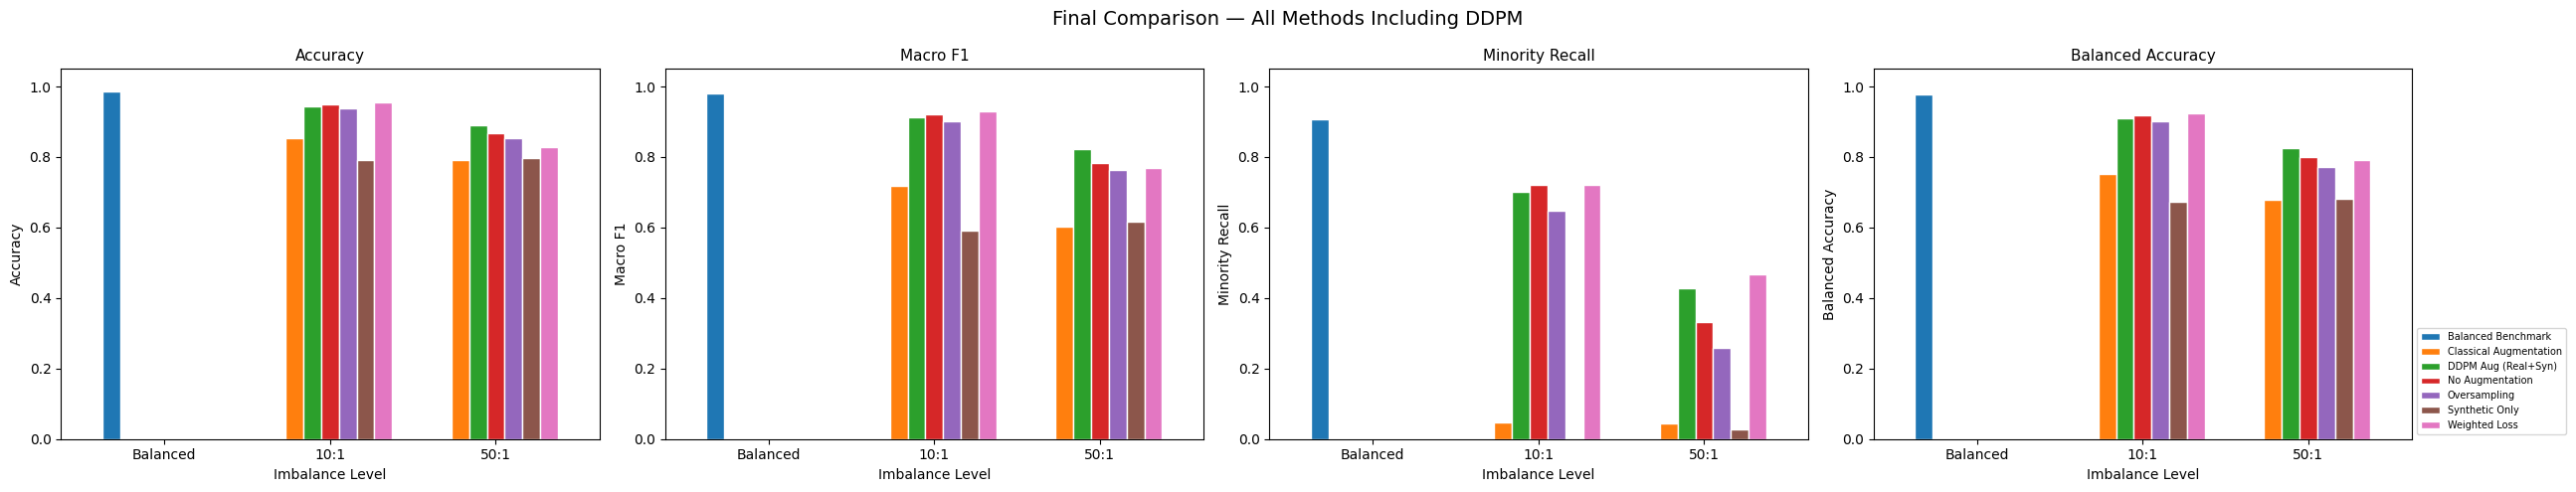

In [ ]:
metrics  = ['Accuracy', 'Macro F1', 'Minority Recall', 'Balanced Accuracy']
imb_lvls = ['Balanced', '10:1', '50:1']
palette  = sns.color_palette('tab10', summary_full['Method'].nunique())

fig, axes = plt.subplots(1, len(metrics), figsize=(26, 5))

for ax, metric in zip(axes, metrics):
    pivot = summary_full.pivot(index='Imbalance', columns='Method', values=metric)
    pivot = pivot.reindex(imb_lvls)
    pivot.plot(kind='bar', ax=ax, color=palette,
               legend=(metric == metrics[-1]),
               edgecolor='white', width=0.75)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel('Imbalance Level')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=0)
    if metric == metrics[-1]:
        ax.legend(loc='lower left', fontsize=7, bbox_to_anchor=(1, 0))

fig.suptitle('Final Comparison — All Methods Including DDPM', fontsize=14)
plt.tight_layout()
plt.savefig('final_all_methods_bar_chart.png', dpi=150)
plt.show()

Minority Recall Line Plot

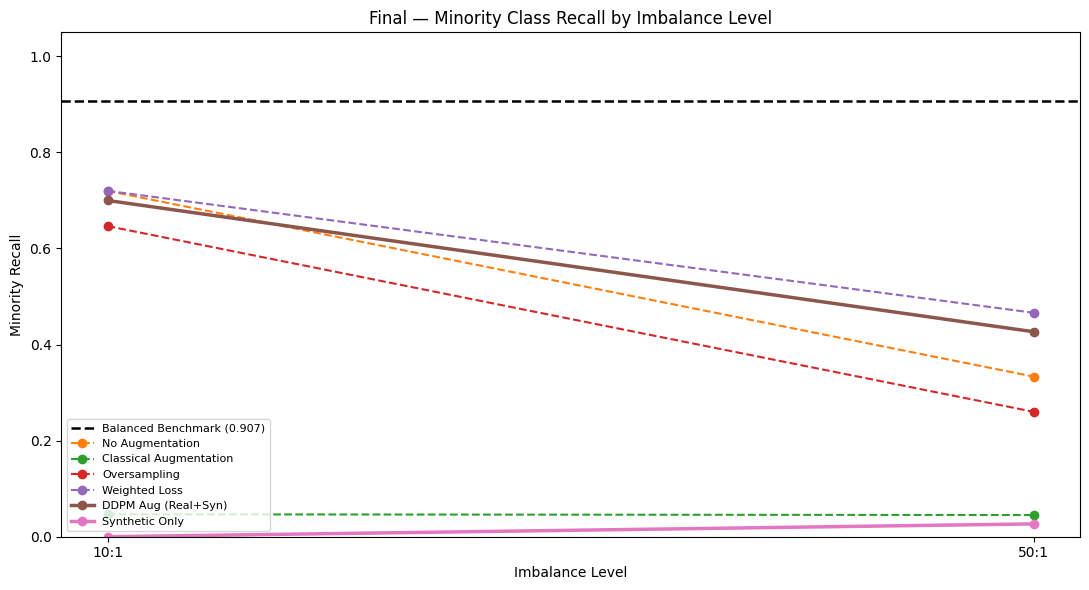

In [ ]:
palette_dict = {m: c for m, c in
                zip(summary_full['Method'].unique(), palette)}

fig, ax = plt.subplots(figsize=(11, 6))

for method in summary_full['Method'].unique():
    sub = summary_full[summary_full['Method'] == method]
    if method == 'Balanced Benchmark':
        val = sub['Minority Recall'].values[0]
        ax.axhline(val, color='black', linestyle='--', linewidth=1.8,
                   label=f'Balanced Benchmark ({val:.3f})')
    else:
        is_ddpm = 'DDPM' in method or 'Synthetic' in method
        lw = 2.5 if is_ddpm else 1.5
        ls = '-'  if is_ddpm else '--'
        ax.plot(sub['Imbalance'], sub['Minority Recall'],
                marker='o', linewidth=lw, linestyle=ls,
                label=method, color=palette_dict[method])

ax.set_title('Final — Minority Class Recall by Imbalance Level')
ax.set_xlabel('Imbalance Level')
ax.set_ylabel('Minority Recall')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=8, bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.savefig('final_minority_recall_plot.png', dpi=150)
plt.show()

Performance Drop Plot

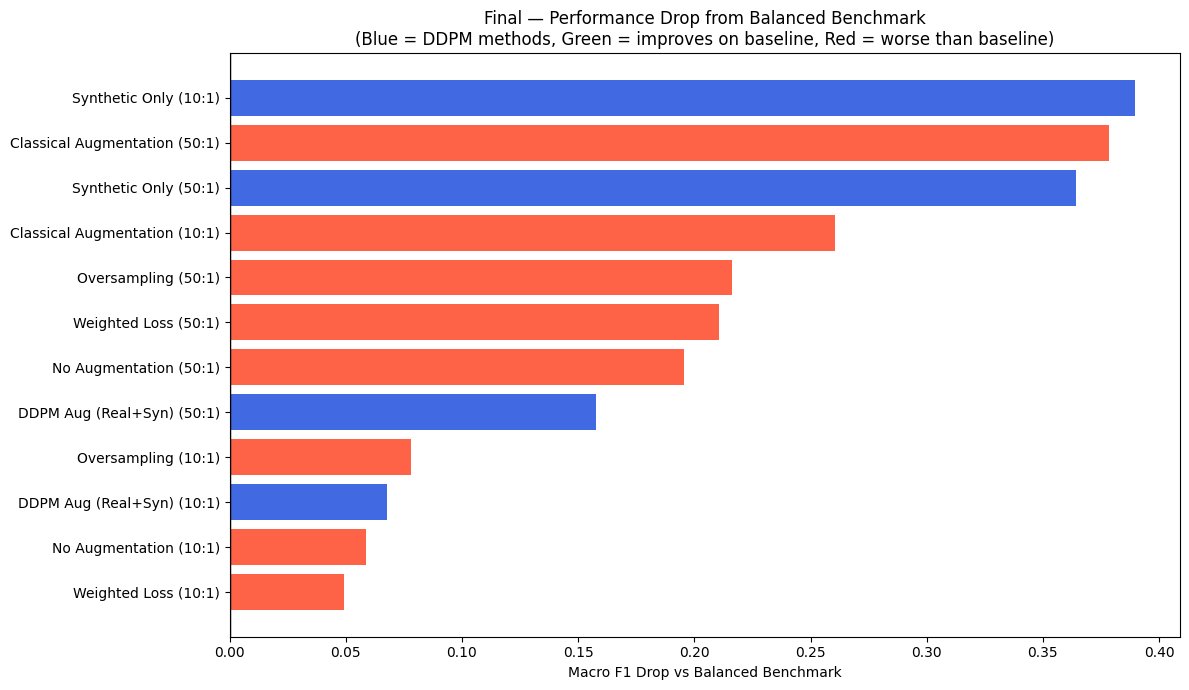


✅ All done!


,Method,Imbalance,Accuracy,Macro F1,Minority Recall,Balanced Accuracy
0,Balanced Benchmark,Balanced,0.9867,0.9798,0.9067,0.9772
1,No Augmentation,10:1,0.9494,0.9213,0.7200,0.9189
2,No Augmentation,50:1,0.8665,0.7842,0.3333,0.8004
3,Classical Augmentation,10:1,0.8542,0.7195,0.0467,0.7530
4,Classical Augmentation,50:1,0.7918,0.6015,0.0451,0.6782
5,Oversampling,10:1,0.9391,0.9019,0.6467,0.9008
6,Oversampling,50:1,0.8542,0.7635,0.2600,0.7708
7,Weighted Loss,10:1,0.9545,0.9307,0.7200,0.9244
8,Weighted Loss,50:1,0.8276,0.7694,0.4662,0.7904
9,DDPM Aug (Real+Syn),10:1,0.9427,0.9120,0.7000,0.9093


In [ ]:
benchmark_f1 = results_balanced['macro_f1']
drop_df      = summary_full[
    summary_full['Method'] != 'Balanced Benchmark'
].copy()
drop_df['Drop']  = benchmark_f1 - drop_df['Macro F1']
drop_df['Label'] = drop_df['Method'] + ' (' + drop_df['Imbalance'] + ')'
drop_df          = drop_df.sort_values('Drop', ascending=True)

colors = []
for method, drop in zip(drop_df['Method'], drop_df['Drop']):
    if 'DDPM' in method or 'Synthetic' in method:
        colors.append('royalblue')
    elif drop <= 0:
        colors.append('seagreen')
    else:
        colors.append('tomato')

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(drop_df['Label'], drop_df['Drop'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Macro F1 Drop vs Balanced Benchmark')
ax.set_title('Final — Performance Drop from Balanced Benchmark\n'
             '(Blue = DDPM methods, Green = improves on baseline, '
             'Red = worse than baseline)')
plt.tight_layout()
plt.savefig('final_performance_drop.png', dpi=150)
plt.show()

display(summary_full)

In [ ]:
print('=' * 60)
print('=' * 60)

benchmark_recall = results_balanced['minority_recall']
benchmark_f1_val = results_balanced['macro_f1']

methods_to_check = [
    ('No Augmentation',      '10:1', res_6A_10),
    ('No Augmentation',      '50:1', res_6A_50),
    ('Classical Aug.',       '10:1', res_6B_10),
    ('Classical Aug.',       '50:1', res_6B_50),
    ('Oversampling',         '10:1', res_6C_10),
    ('Oversampling',         '50:1', res_6C_50),
    ('Weighted Loss',        '10:1', res_6D_10),
    ('Weighted Loss',        '50:1', res_6D_50),
    ('DDPM (Real+Syn)',      '10:1', res_ddpm_10),
    ('DDPM (Real+Syn)',      '50:1', res_ddpm_50),
    ('Synthetic Only',       '10:1', res_syn_10),
    ('Synthetic Only',       '50:1', res_syn_50),
]

print(f'\nBalanced Benchmark (upper bound):')
print(f'  Macro F1       : {benchmark_f1_val:.4f}')
print(f'  Minority Recall: {benchmark_recall:.4f}')

print(f'\n{"Method":<25} {"Imbalance":<10} '
      f'{"Macro F1":<12} {"Min. Recall":<14} {"vs Benchmark"}')
print('-' * 75)
for name, imb, res in methods_to_check:
    f1_gap  = res['macro_f1']      - benchmark_f1_val
    rec_gap = res['minority_recall'] - benchmark_recall
    flag    = '' if ('DDPM' in name or 'Synthetic' in name) else ' '
    print(f'{flag} {name:<23} {imb:<10} '
          f'{res["macro_f1"]:.4f}{"":>6} '
          f'{res["minority_recall"]:.4f}{"":>8} '
          f'F1: {f1_gap:+.4f}  Rec: {rec_gap:+.4f}')



best_ddpm_rec  = max(res_ddpm_10['minority_recall'],
                     res_ddpm_50['minority_recall'])
best_base_rec  = max(res_6D_10['minority_recall'],
                     res_6D_50['minority_recall'])
if best_ddpm_rec >= best_base_rec:
    print(f'  → YES: DDPM ({best_ddpm_rec:.3f}) ≥ best classical '
          f'({best_base_rec:.3f})')
else:
    print(f'  → PARTIALLY: DDPM ({best_ddpm_rec:.3f}) vs best classical '
          f'({best_base_rec:.3f})')
    print(f'     Gap = {best_ddpm_rec - best_base_rec:+.3f}')

FINAL FINDINGS SUMMARY

Balanced Benchmark (upper bound):
  Macro F1       : 0.9798
  Minority Recall: 0.9067

Method                    Imbalance  Macro F1     Min. Recall    vs Benchmark
---------------------------------------------------------------------------
  No Augmentation         10:1       0.9213       0.7200         F1: -0.0586  Rec: -0.1867
  No Augmentation         50:1       0.7842       0.3333         F1: -0.1957  Rec: -0.5733
  Classical Aug.          10:1       0.7195       0.0467         F1: -0.2603  Rec: -0.8600
  Classical Aug.          50:1       0.6015       0.0451         F1: -0.3783  Rec: -0.8616
  Oversampling            10:1       0.9019       0.6467         F1: -0.0780  Rec: -0.2600
  Oversampling            50:1       0.7635       0.2600         F1: -0.2163  Rec: -0.6467
  Weighted Loss           10:1       0.9307       0.7200         F1: -0.0491  Rec: -0.1867
  Weighted Loss           50:1       0.7694       0.4662         F1: -0.2104  Rec: -0.4405
★ DDPM 